# Exploratory Data Analysis – Amazing International Airlines (AIAI)

**Group 68**

## 1. Business & Data Understanding

**Business Objective**: Identify distinct customer segments within AIAI's loyalty program to enable targeted marketing strategies and improve customer retention.

**Data Sources**:
- `DM_AIAI_CustomerDB.csv`: Customer demographics and loyalty information
- `DM_AIAI_FlightsDB.csv`: Monthly flight activity records

**Expected Outcome**: Clean, merged dataset with engineered features ready for clustering analysis.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load customer and flight databases
df_customer = pd.read_csv('Data/DM_AIAI_CustomerDB.csv')
df_flights = pd.read_csv('Data/DM_AIAI_FlightsDB.csv')

print(f"Customer records: {df_customer.shape[0]:,} rows × {df_customer.shape[1]} columns")
print(f"Flight records: {df_flights.shape[0]:,} rows × {df_flights.shape[1]} columns")

Customer records: 16,921 rows × 21 columns
Flight records: 608,436 rows × 10 columns


In [3]:
# Display first few rows of customer database
df_customer.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [4]:
# Display first few rows of flights database
df_flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [5]:
# Remove unnecessary index column
df_customer.drop(columns=['Unnamed: 0'], inplace=True)
print("✓ Removed 'Unnamed: 0' column")
df_customer.head()

✓ Removed 'Unnamed: 0' column


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [6]:
df_customer.describe()

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value
count,16921.000000,16921.000000,16921.000000,16901.000000,16901.000000
mean,550197.393771,47.174500,-91.814768,37758.038400,7990.460188
std,259251.503597,3.307971,22.242429,30368.992499,6863.173093
min,100011.000000,42.984924,-135.056840,0.000000,1898.010000
25%,326823.000000,44.231171,-120.237660,0.000000,3979.720000
50%,550896.000000,46.087818,-79.383186,34161.000000,5780.180000
75%,772438.000000,49.282730,-74.596184,62396.000000,8945.690000
max,999999.000000,60.721188,-52.712578,99981.000000,83325.380000


In [7]:
df_flights.describe()

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
count,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000,608436.000000
mean,550037.873084,2020.000000,6.500000,3.908107,0.983944,7939.341419,793.777781,235.251678,2.324835
std,258935.180575,0.816497,3.452055,5.057889,2.003785,10260.421873,1025.918521,983.233374,9.725168
min,100018.000000,2019.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326961.000000,2019.000000,3.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,550834.000000,2020.000000,6.500000,0.000000,0.000000,856.400000,85.275000,0.000000,0.000000
75%,772194.000000,2021.000000,9.250000,7.200000,0.900000,15338.175000,1533.712500,0.000000,0.000000
max,999986.000000,2021.000000,12.000000,21.000000,11.000000,42040.000000,4204.000000,7496.000000,74.000000


In [8]:
df_customer.info()

df_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loyalty#                 16921 non-null  int64  
 1   First Name               16921 non-null  object 
 2   Last Name                16921 non-null  object 
 3   Customer Name            16921 non-null  object 
 4   Country                  16921 non-null  object 
 5   Province or State        16921 non-null  object 
 6   City                     16921 non-null  object 
 7   Latitude                 16921 non-null  float64
 8   Longitude                16921 non-null  float64
 9   Postal code              16921 non-null  object 
 10  Gender                   16921 non-null  object 
 11  Education                16921 non-null  object 
 12  Location Code            16921 non-null  object 
 13  Income                   16901 non-null  float64
 14  Marital Status        

**Initial Observations**:
- Customer database contains demographic information (gender, education, marital status) and loyalty metrics
- Flights database tracks monthly activity including distance, points, and companion flights
- Some columns require data type conversions (dates, integers)

## 2. Data Quality Assessment

This section identifies and addresses data quality issues including duplicates, missing values, incorrect data types, and outliers.

In [9]:
# Fix data types: convert dates and flight counts
df_customer['EnrollmentDateOpening'] = pd.to_datetime(df_customer['EnrollmentDateOpening'], errors='coerce')
df_customer['CancellationDate'] = pd.to_datetime(df_customer['CancellationDate'], errors='coerce')
df_flights['YearMonthDate'] = pd.to_datetime(df_flights['YearMonthDate'], errors='coerce')

# Round the float values to the nearest integer before converting to Int64
df_flights['NumFlights'] = df_flights['NumFlights'].round().astype('Int64')
df_flights['NumFlightsWithCompanions'] = df_flights['NumFlightsWithCompanions'].round().astype('Int64')

In [10]:
# Unique value counts for all object columns
cat_summary = (df_customer.select_dtypes(include='object').nunique().sort_values(ascending=False).to_frame(name='Unique_Values'))

print("Categorical Column Cardinality:")
display(cat_summary)

for col in df_customer.select_dtypes(include='object').columns:
    uniques = df_customer[col].dropna().unique()
    print(f"\n--- {col} ---")
    print(f"{len(uniques)} unique values")
    print(uniques[:10])

Categorical Column Cardinality:


,Unique_Values
Customer Name,16921
Last Name,15404
First Name,4941
Postal code,75
City,29
Province or State,11
Education,5
Location Code,3
Marital Status,3
LoyaltyStatus,3



--- First Name ---
4941 unique values
['Cecilia' 'Dayle' 'Necole' 'Queen' 'Claire' 'Leatrice' 'Hue' 'Nakia'
 'Arlene' 'Dustin']

--- Last Name ---
15404 unique values
['Householder' 'Menez' 'Hannon' 'Hagee' 'Latting' 'Hanlin' 'Sellner'
 'Cash' 'Conterras' 'Recine']

--- Customer Name ---
16921 unique values
['Cecilia Householder' 'Dayle Menez' 'Necole Hannon' 'Queen Hagee'
 'Claire Latting' 'Leatrice Hanlin' 'Hue Sellner' 'Nakia Cash'
 'Arlene Conterras' 'Dustin Recine']

--- Country ---
1 unique values
['Canada']

--- Province or State ---
11 unique values
['Ontario' 'Alberta' 'British Columbia' 'Quebec' 'Yukon' 'New Brunswick'
 'Manitoba' 'Nova Scotia' 'Saskatchewan' 'Newfoundland']

--- City ---
29 unique values
['Toronto' 'Edmonton' 'Vancouver' 'Hull' 'Whitehorse' 'Trenton' 'Montreal'
 'Dawson Creek' 'Quebec City' 'Moncton']

--- Postal code ---
75 unique values
['M2Z 4K1' 'T3G 6Y6' 'V6E 3D9' 'P1W 1K4' 'J8Y 3Z5' 'Y2K 6R0' 'P5S 6R4'
 'K8V 4B2' 'H2Y 2W2' 'M8Y 4K8']

--- Gender ---
2

In [11]:
# Check for duplicate customer records
dups_customers = df_customer.duplicated(subset=['Loyalty#']).sum()
print(f"Duplicate Loyalty# in CustomerDB: {dups_customers}")

if dups_customers > 0:
    print("\nInspecting duplicates:")
    display(df_customer[df_customer.duplicated(subset=['Loyalty#'], keep=False)])
    
    # Remove duplicates, keeping first occurrence
    df_customer = df_customer.drop_duplicates(subset=['Loyalty#'], keep='first')
    print(f"✓ Removed {dups_customers} duplicate customer records")
else:
    print("✓ No duplicate customers found")

Duplicate Loyalty# in CustomerDB: 164

Inspecting duplicates:


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
5,193662,Leatrice,Hanlin,Leatrice Hanlin,Canada,Yukon,Whitehorse,60.721188,-135.056840,Y2K 6R0,male,Bachelor,Rural,26262.0,Married,Star,2015-05-07,NaT,3844.57,Standard
123,746226,Theodora,Sampieri,Theodora Sampieri,Canada,British Columbia,Whistler,50.116322,-122.957360,V6T 1Y8,female,Bachelor,Urban,43177.0,Married,Star,2021-01-17,NaT,4089.04,Standard
141,279419,Reyes,Sobczak,Reyes Sobczak,Canada,British Columbia,West Vancouver,49.328625,-123.160190,V6V 8Z3,female,College,Urban,0.0,Single,Star,2016-07-03,NaT,4117.37,Standard
161,354438,Maricela,Veals,Maricela Veals,Canada,Quebec,Montreal,45.501690,-73.567253,H2T 2J6,male,College,Rural,0.0,Married,Star,2021-09-01,NaT,4167.09,Standard
204,719633,Elnora,Holzmiller,Elnora Holzmiller,Canada,British Columbia,Victoria,48.428421,-123.365650,V10 6T5,male,Bachelor,Suburban,27608.0,Divorced,Star,2019-12-03,NaT,4250.78,Standard
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16488,373638,Sherryl,Vanduyn,Sherryl Vanduyn,Canada,Quebec,Tremblant,46.118462,-74.596184,H5Y 2S9,female,College,Rural,0.0,Single,Star,2021-07-30,NaT,18898.33,Standard
16625,727507,Marnie,Kisner,Marnie Kisner,Canada,Alberta,Banff,51.178398,-115.570800,T4V 1D4,male,Bachelor,Suburban,93011.0,Divorced,Star,2020-12-26,NaT,22643.83,Standard
16766,278854,Marylee,Villicana,Marylee Villicana,Canada,Quebec,Tremblant,46.118462,-74.596184,H5Y 2S9,female,High School or Below,Urban,20799.0,Single,Star,2017-08-16,NaT,28328.47,Standard
16775,434807,Cira,Nalley,Cira Nalley,Canada,Alberta,Edmonton,53.544388,-113.490930,T9G 1W3,male,Bachelor,Rural,35296.0,Single,Star,2015-08-27,NaT,29194.37,Standard


✓ Removed 164 duplicate customer records


In [12]:
df_customer = df_customer.drop_duplicates(subset=['Loyalty#'], keep='first')

In [13]:
# Check for duplicate flight records (same customer, year, month)
dups_flights = df_flights.duplicated(subset=['Loyalty#', 'Year', 'Month']).sum()
print(f"Duplicate (Loyalty#, Year, Month) rows in FlightsDB: {dups_flights}")

if dups_flights > 0:
    print("\nInspecting duplicates:")
    display(df_flights[df_flights.duplicated(subset=['Loyalty#', 'Year', 'Month'], keep=False)])
    
    # Remove duplicates, keeping first occurrence
    df_flights = df_flights.drop_duplicates(subset=['Loyalty#', 'Year', 'Month'], keep='first')
    print(f"✓ Removed {dups_flights} duplicate flight records")
else:
    print("✓ No duplicate flight records found")

Duplicate (Loyalty#, Year, Month) rows in FlightsDB: 5904

Inspecting duplicates:


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
27,279419,2021,12,2021-12-01,12,0,11849.0,1184.00,0.0,0.0
171,990512,2021,12,2021-12-01,5,2,31991.0,3199.00,0.0,0.0
248,322169,2021,12,2021-12-01,2,0,17125.0,1712.00,0.0,0.0
297,106001,2021,12,2021-12-01,7,0,26469.0,2646.00,0.0,0.0
450,727091,2021,12,2021-12-01,0,0,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
608249,989528,2019,12,2019-12-01,0,0,0.0,0.00,0.0,0.0
608263,990512,2019,12,2019-12-01,0,0,0.0,0.00,0.0,0.0
608264,990512,2019,12,2019-12-01,0,0,0.0,0.00,0.0,0.0
608298,992168,2019,12,2019-12-01,12,4,2987.1,298.71,0.0,0.0


✓ Removed 5904 duplicate flight records


In [14]:
df_flights = df_flights.drop_duplicates(subset=['Loyalty#','Year','Month'], keep='first')

In [15]:
# Merge datasets using inner join to retain only customers with flight activity
df_final = pd.merge(df_customer, df_flights, on='Loyalty#', how='inner')

print(f"Merged dataset: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"Unique customers: {df_final['Loyalty#'].nunique():,}")

# Check missing values
missing_summary = df_final.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
if len(missing_summary) > 0:
    display(pd.DataFrame({
        'Missing_Count': missing_summary,
        'Missing_Percentage': (missing_summary / len(df_final) * 100).round(2)
    }))

Merged dataset: 602,532 rows × 29 columns
Unique customers: 16,737


,Missing_Count,Missing_Percentage
CancellationDate,520956,86.46


In [16]:
df_final.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,2020,5,2020-05-01,13,4,25010.0,2501.0,0.0,0.0
1,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,2020,4,2020-04-01,0,0,5095.0,509.0,0.0,0.0
2,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,2020,2,2020-02-01,3,0,24271.0,2427.0,0.0,0.0
3,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,2020,3,2020-03-01,0,0,0.0,0.0,0.0,0.0
4,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2019-02-15,NaT,3839.14,Standard,2020,1,2020-01-01,0,0,0.0,0.0,0.0,0.0


**Data Quality Summary**:
- Duplicates removed from both datasets ensuring unique customer-month records
- Inner join strategy ensures only active customers with valid flight history are retained
- Date columns properly formatted for temporal analysis
- Missing values assessed and will be handled during feature engineering

## 3. Descriptive Statistics

Comprehensive statistical analysis and visualization of all variables to understand distributions, detect outliers, and identify patterns.

In [17]:
# Display summary statistics for numerical variables
df_final.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Loyalty#,602532.0,549735.880445,100018.0,326603.0,550434.0,772019.0,999986.0,258904.612462
Latitude,602532.0,47.176063,42.984924,44.231171,46.087818,49.28273,60.721188,3.306169
Longitude,602532.0,-91.836855,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578,22.244217
Income,602532.0,37749.877696,0.0,0.0,34148.0,62396.0,99981.0,30369.454458
EnrollmentDateOpening,602532,2018-10-06 20:55:11.561211904,2015-04-01 00:00:00,2017-01-18 00:00:00,2018-11-02 00:00:00,2020-07-10 00:00:00,2021-12-30 00:00:00,NaN
CancellationDate,81576,2019-12-19 05:11:23.142100480,2015-11-30 00:00:00,2019-02-01 00:00:00,2020-01-14 00:00:00,2021-02-16 00:00:00,2021-12-30 00:00:00,NaN
Customer Lifetime Value,602532.0,7988.896536,1898.01,3980.84,5780.18,8940.58,83325.38,6860.783006
Year,602532.0,2020.0,2019.0,2019.0,2020.0,2021.0,2021.0,0.816497
Month,602532.0,6.5,1.0,3.75,6.5,9.25,12.0,3.452055
YearMonthDate,602532,2020-06-16 02:39:59.999999744,2019-01-01 00:00:00,2019-09-23 12:00:00,2020-06-16 00:00:00,2021-03-08 18:00:00,2021-12-01 00:00:00,NaN


In [18]:
# Analyze categorical features
cat_summary = df_final.select_dtypes(include='object').nunique().sort_values(ascending=False).to_frame(name='Unique_Values')

display(cat_summary)

# Display unique values for each categorical column
for col in df_final.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df_final[col].value_counts())

,Unique_Values
Customer Name,16737
Last Name,15250
First Name,4933
Postal code,55
City,29
Province or State,11
Education,5
Location Code,3
Marital Status,3
LoyaltyStatus,3



--- First Name ---
First Name
Stacey       468
Deon         468
Rudy         432
Loren        432
Merrill      432
            ... 
Georgette     36
Nova          36
Kenya         36
Tiera         36
Juliann       36
Name: count, Length: 4933, dtype: int64

--- Last Name ---
Last Name
Ypina        144
Salberg      144
Walk         108
Froehlich    108
Sempek       108
            ... 
Amos          36
Manthey       36
Mcumber       36
Levesque      36
Peyton        36
Name: count, Length: 15250, dtype: int64

--- Customer Name ---
Customer Name
Cecilia Householder    36
Mila Hust              36
Gwen Lafleche          36
Mikaela Boulter        36
Manual Fails           36
                       ..
Lory Minneweather      36
Bianca Hiscox          36
Adrian Mihaly          36
Edris Hecker           36
Ariane Peyton          36
Name: count, Length: 16737, dtype: int64

--- Country ---
Country
Canada    602532
Name: count, dtype: int64

--- Province or State ---
Province or State
Ontario 

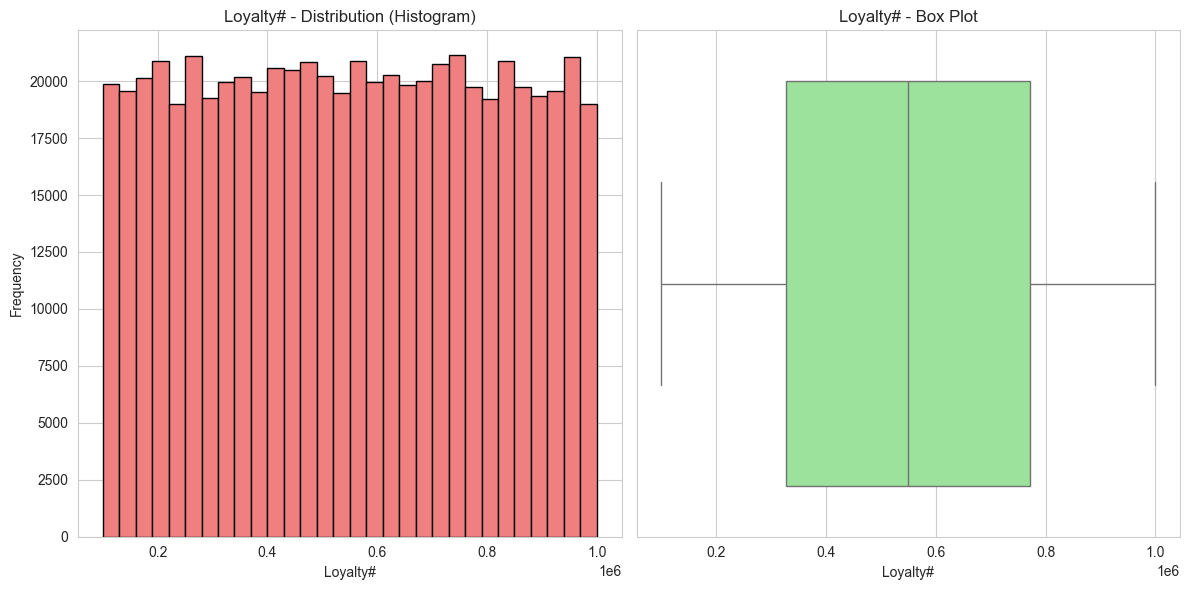

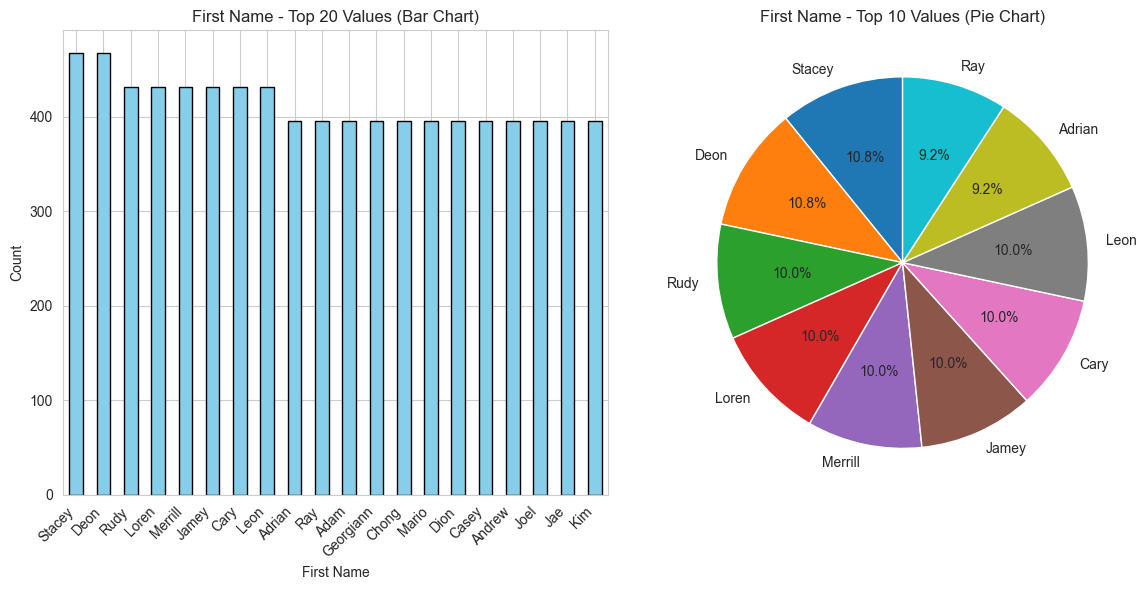

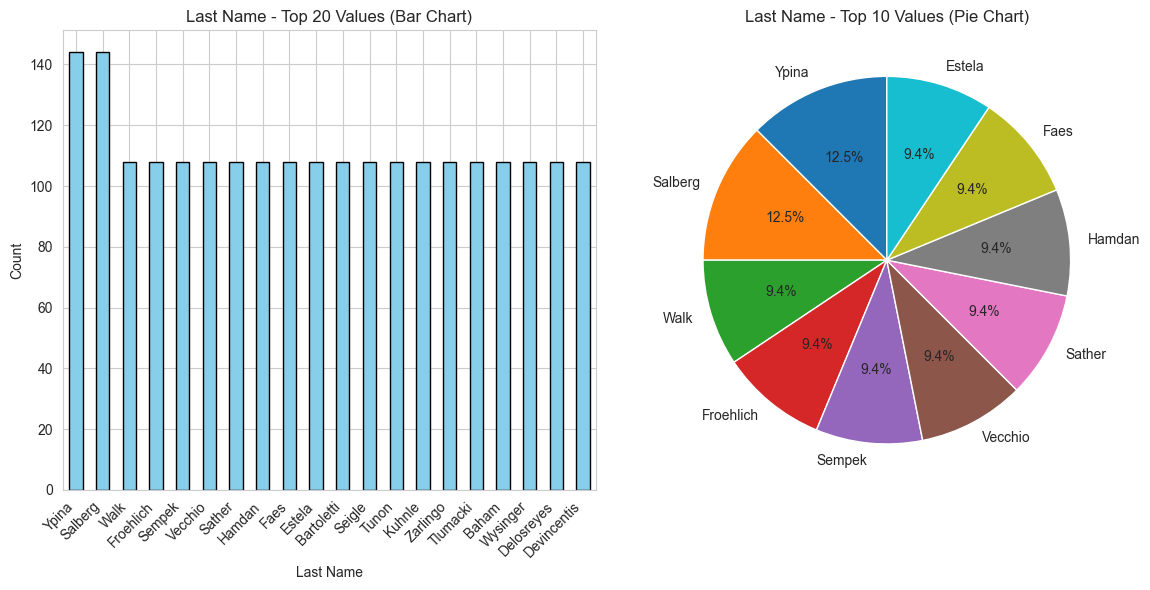

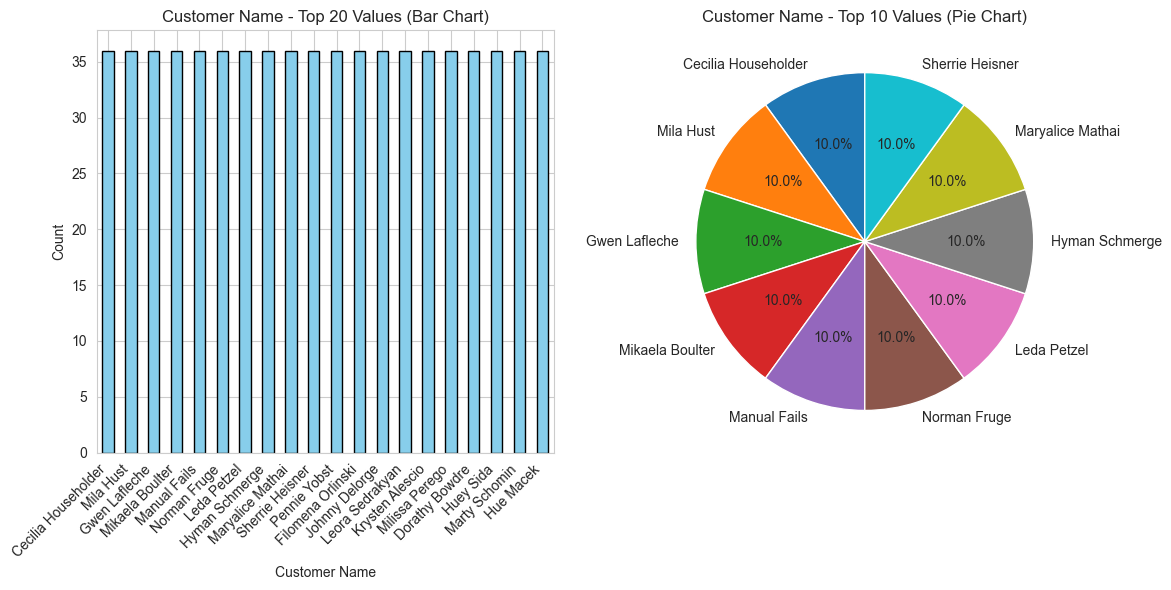

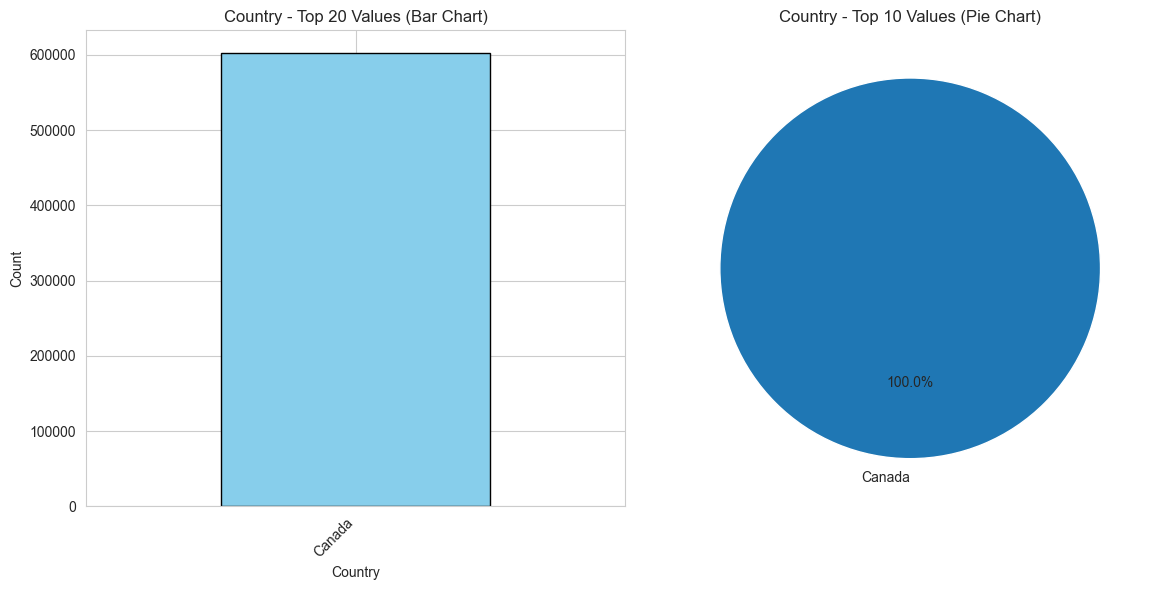

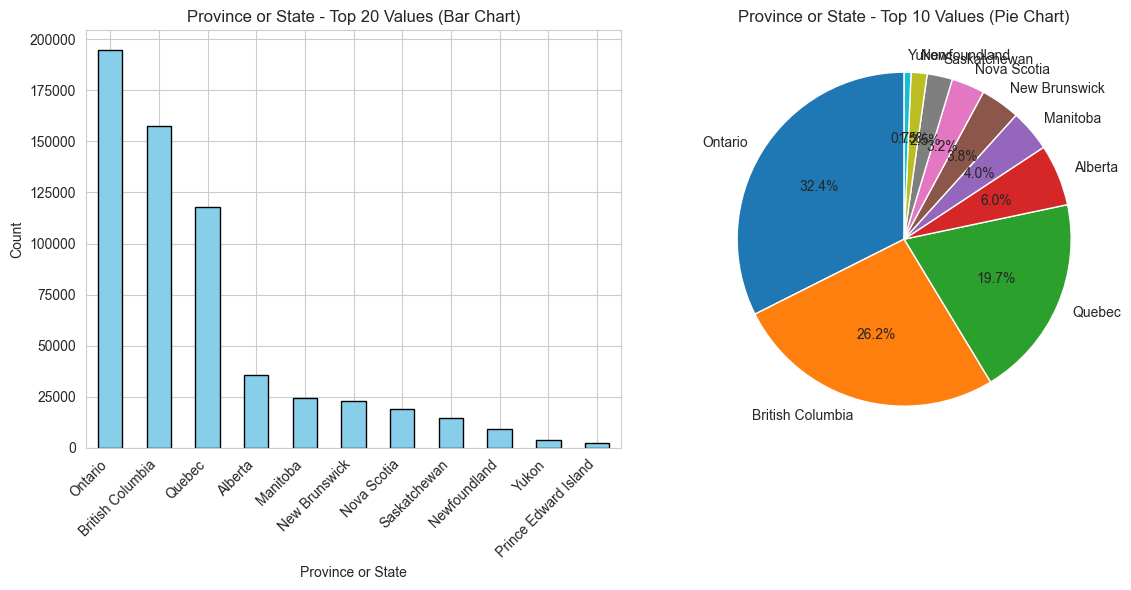

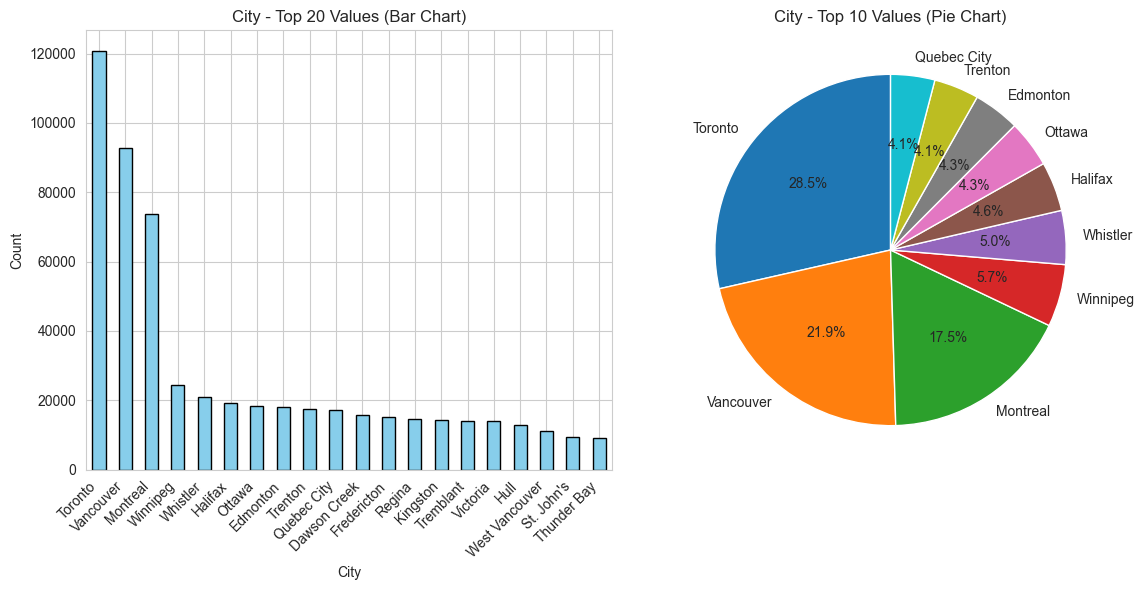

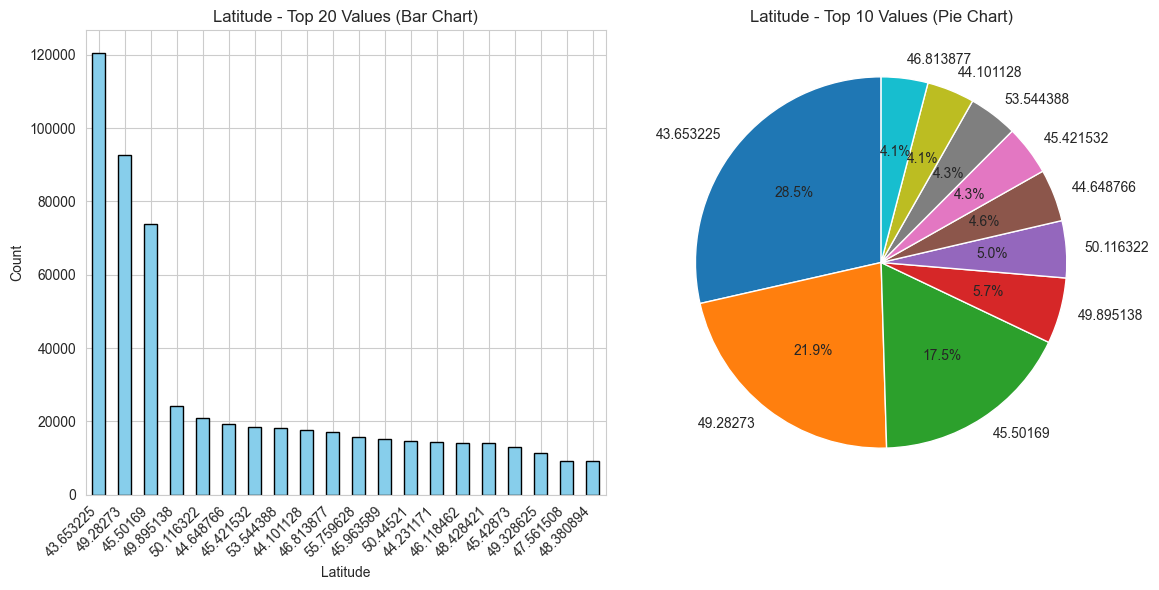

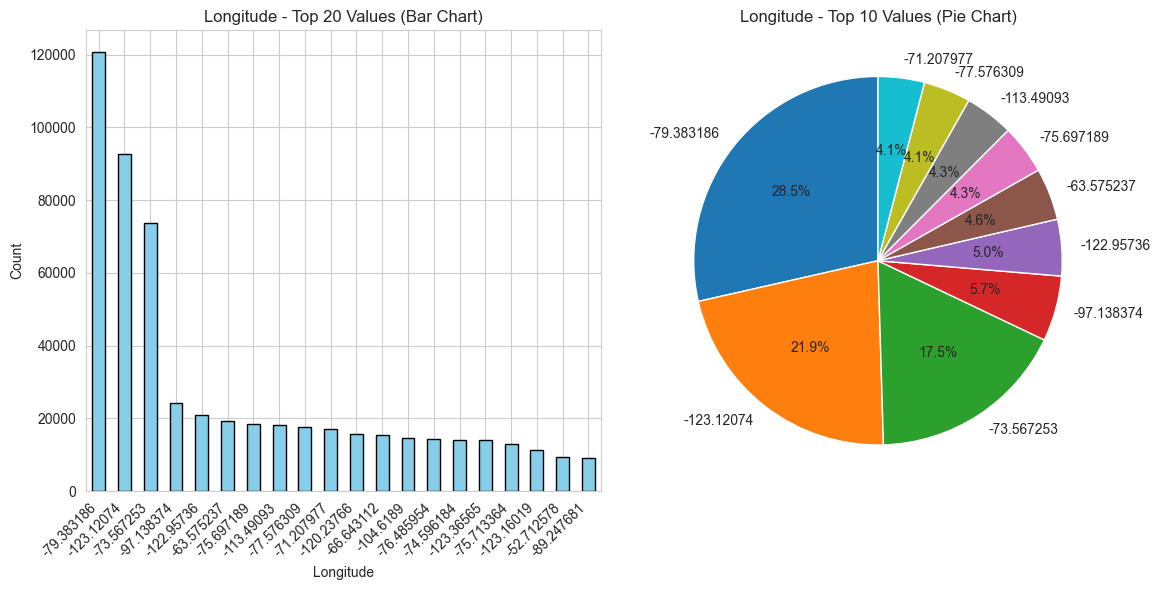

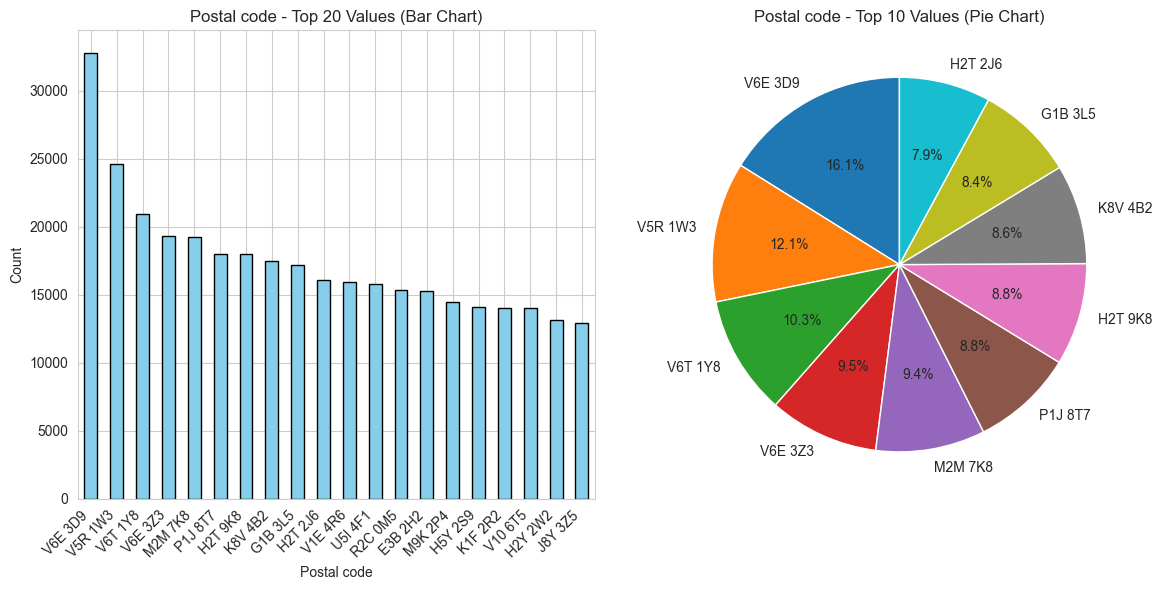

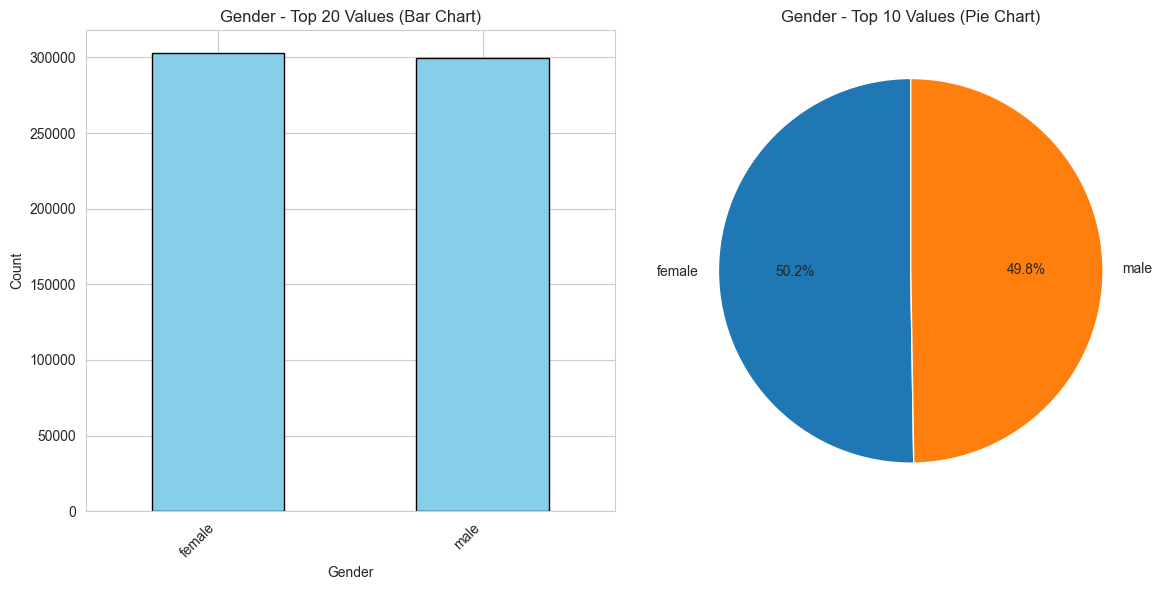

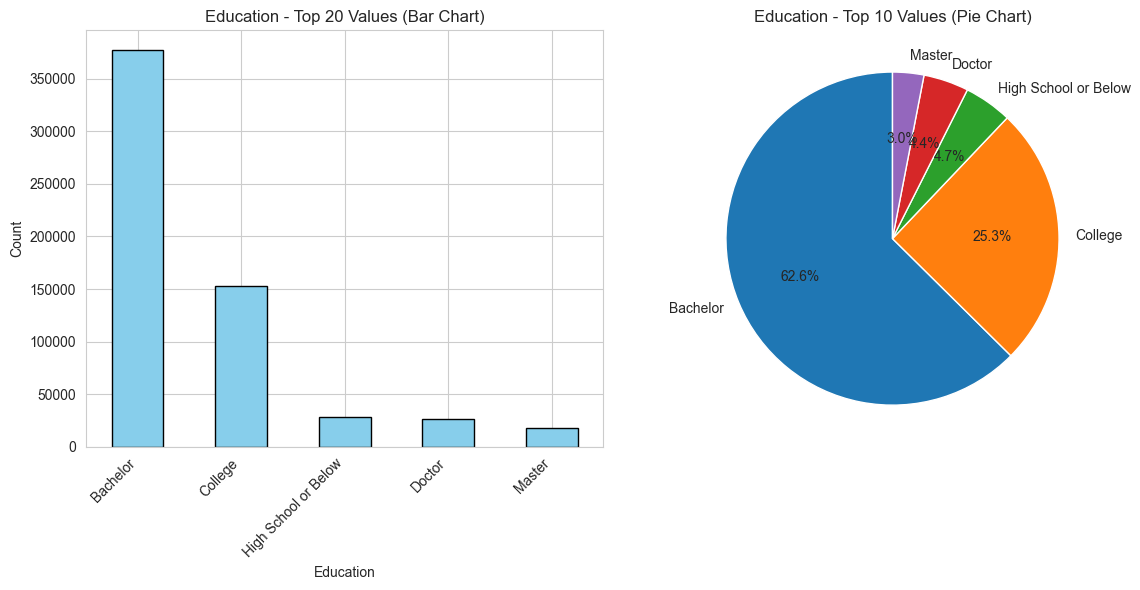

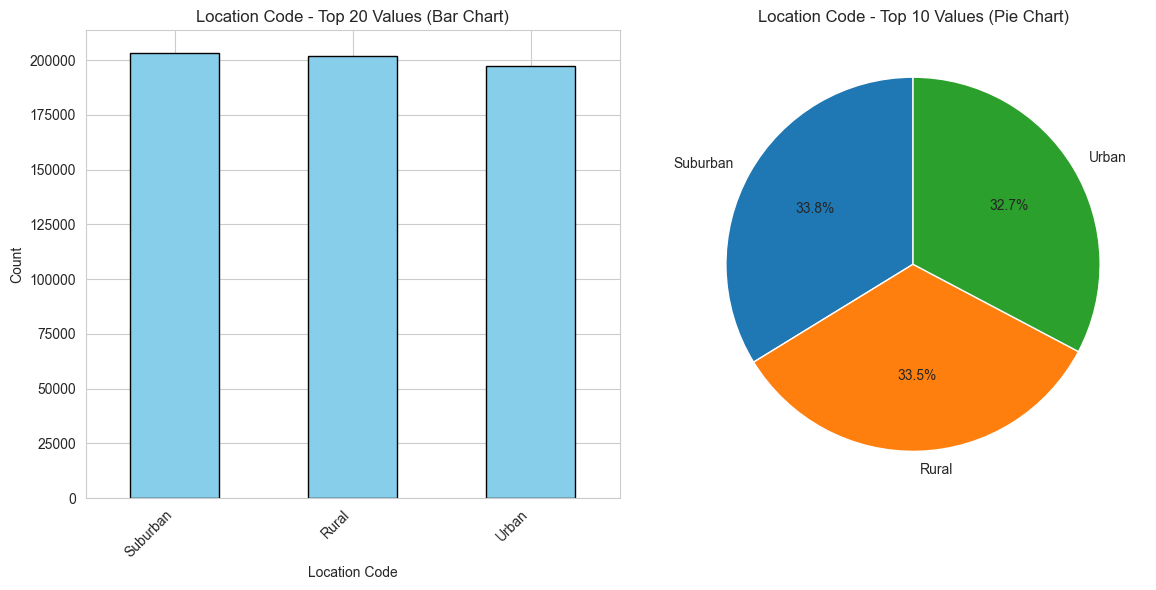

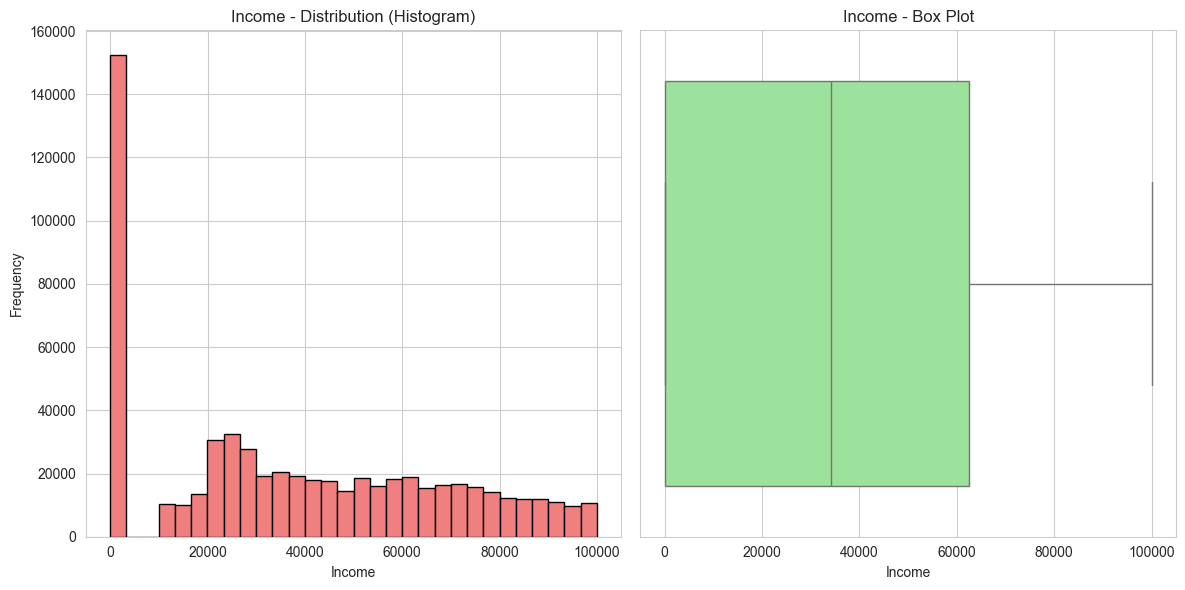

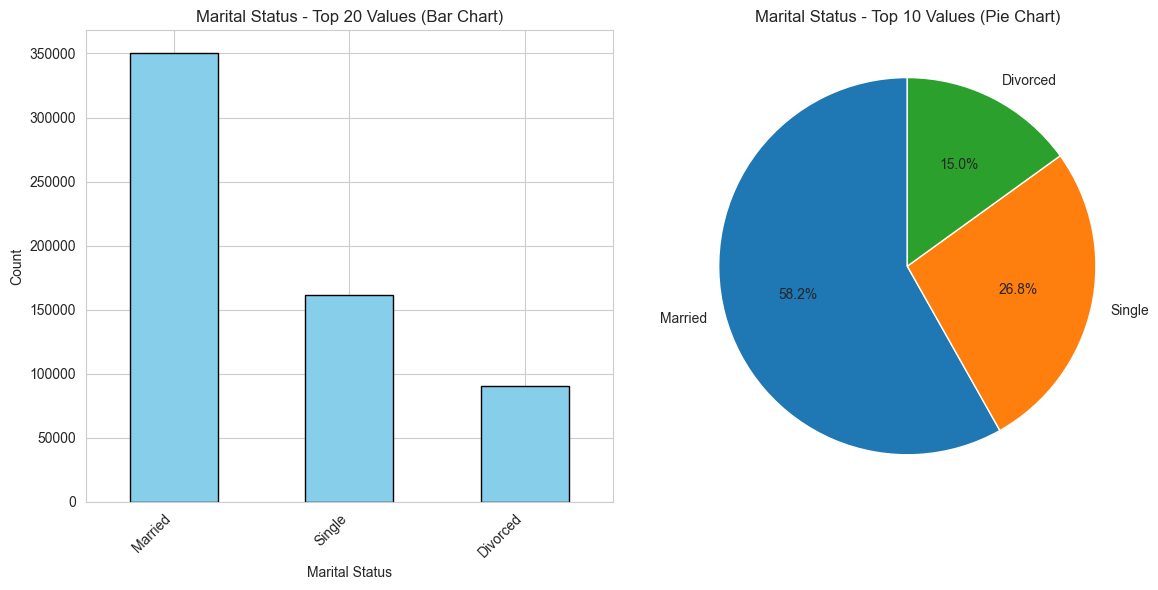

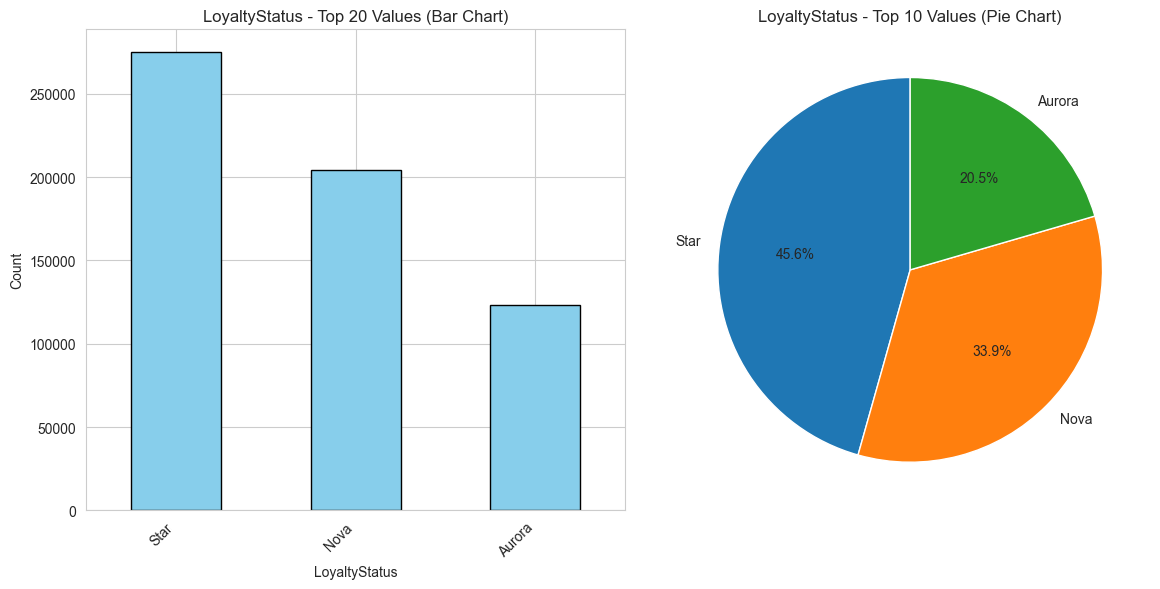

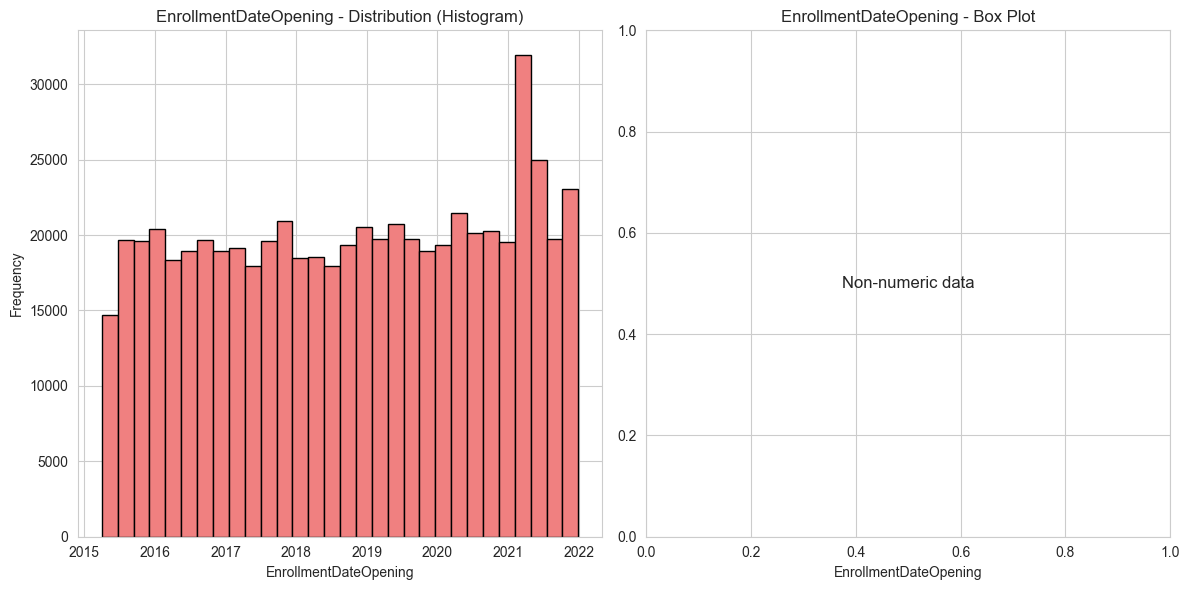

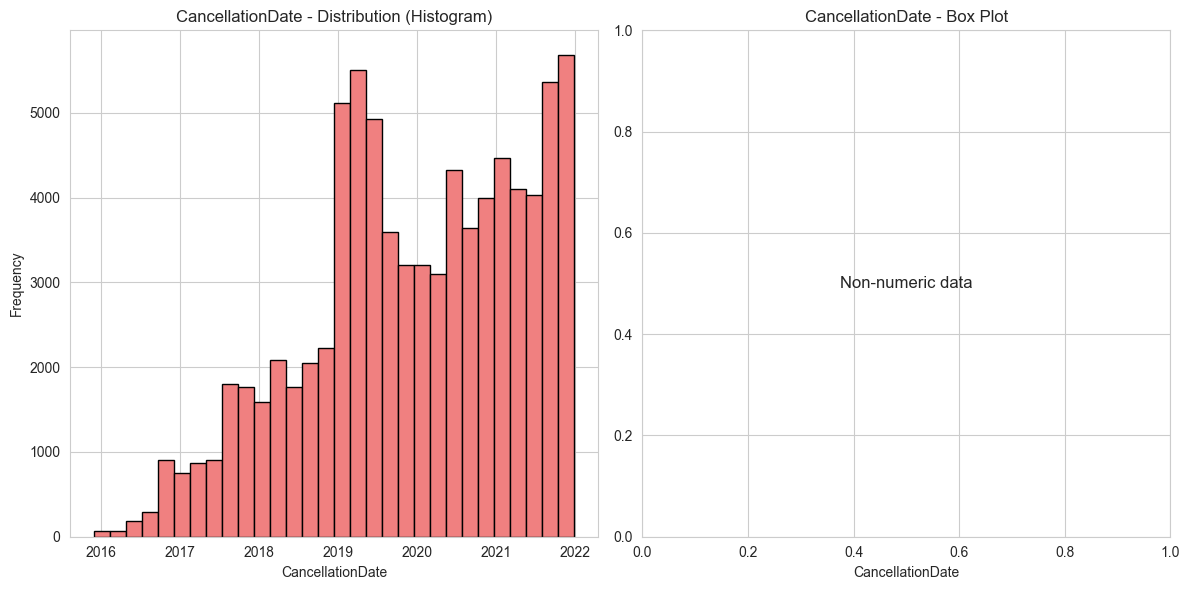

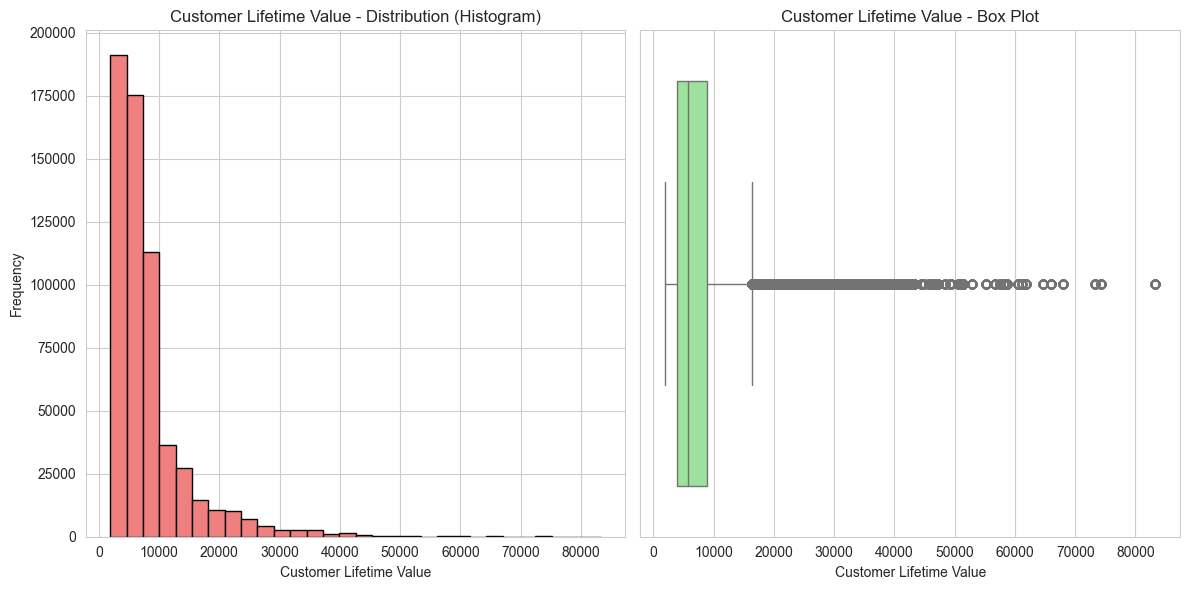

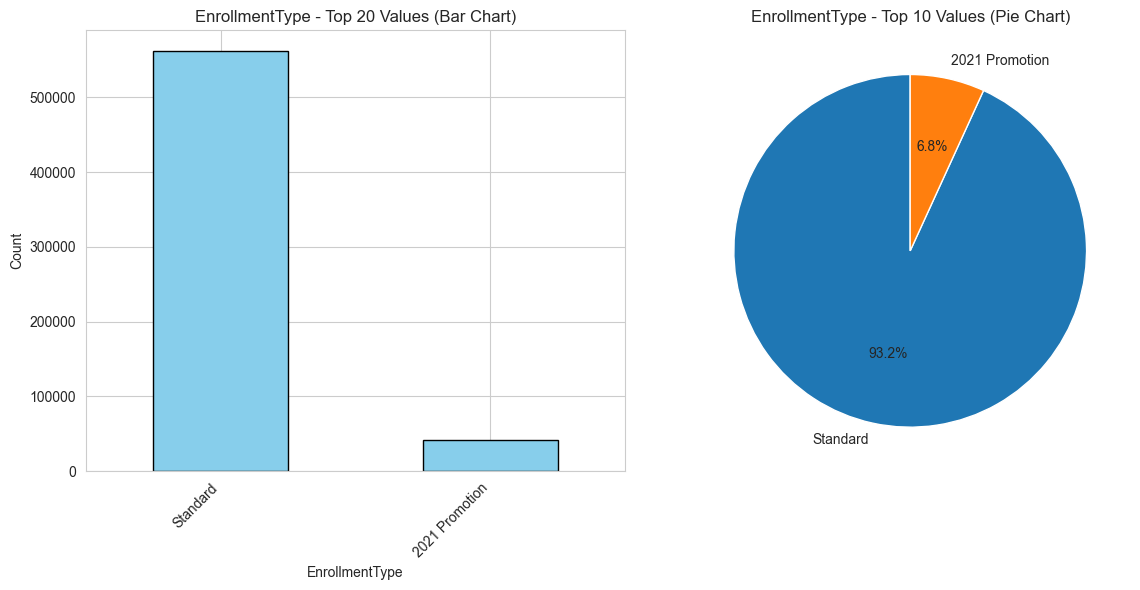

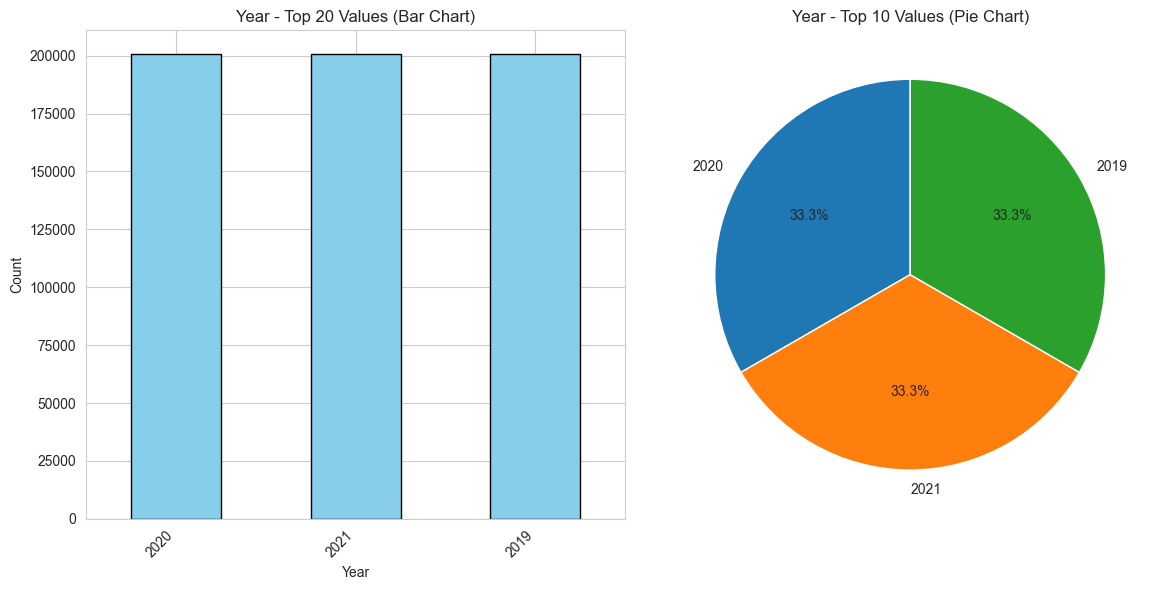

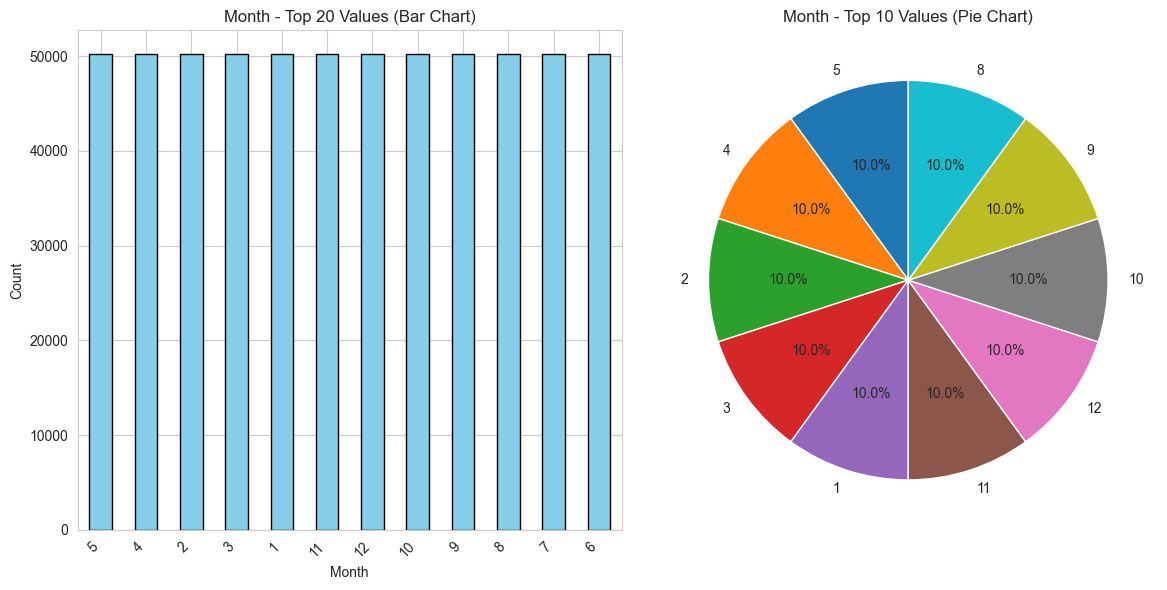

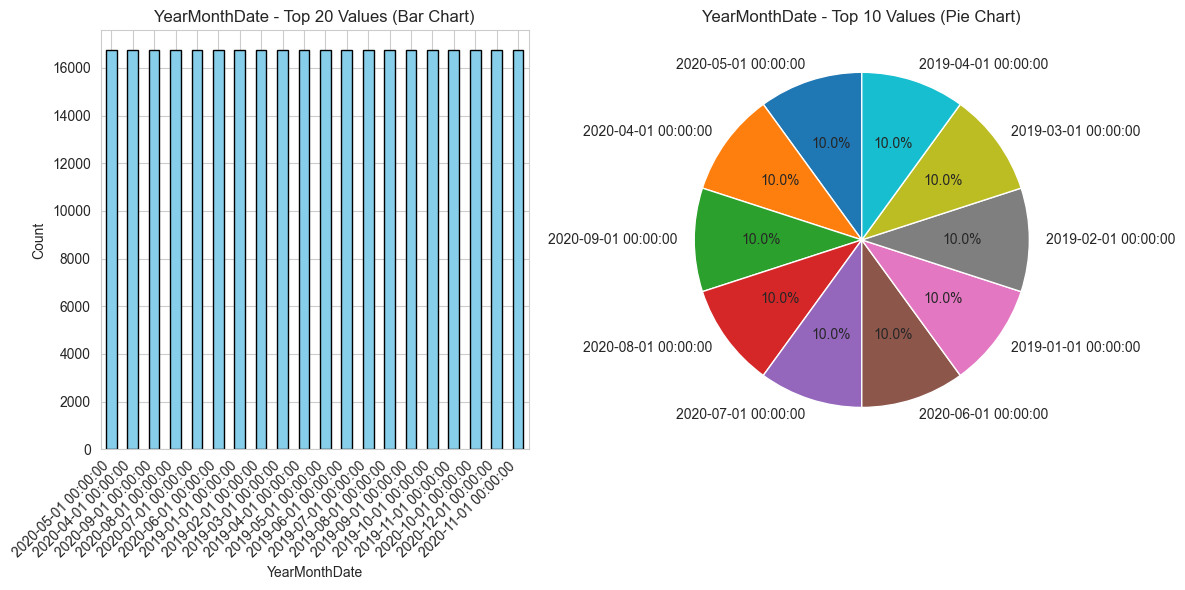

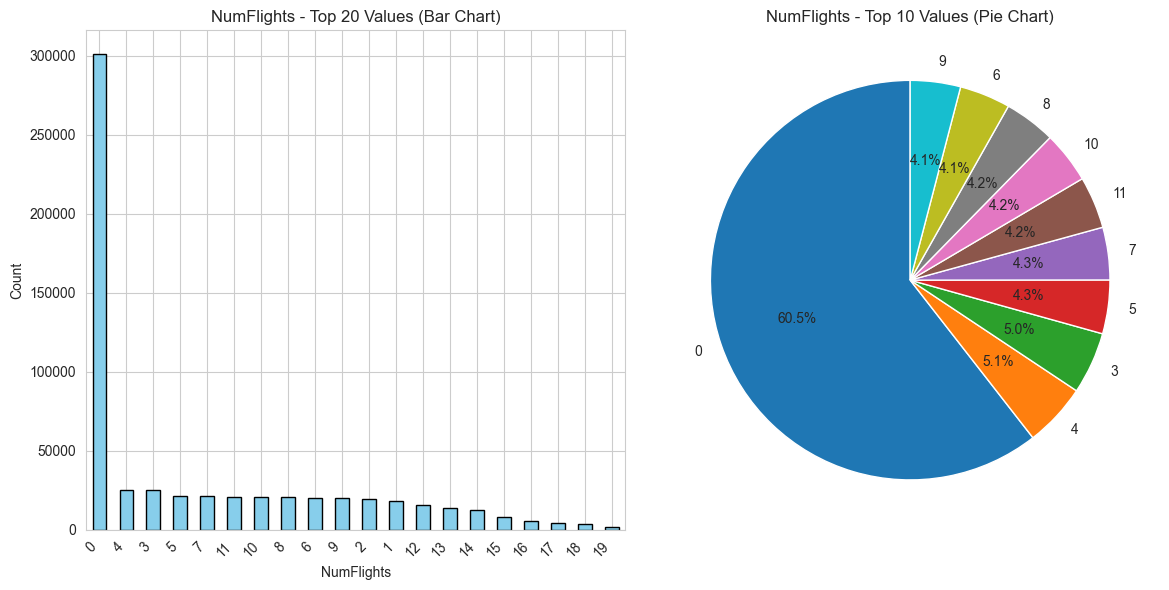

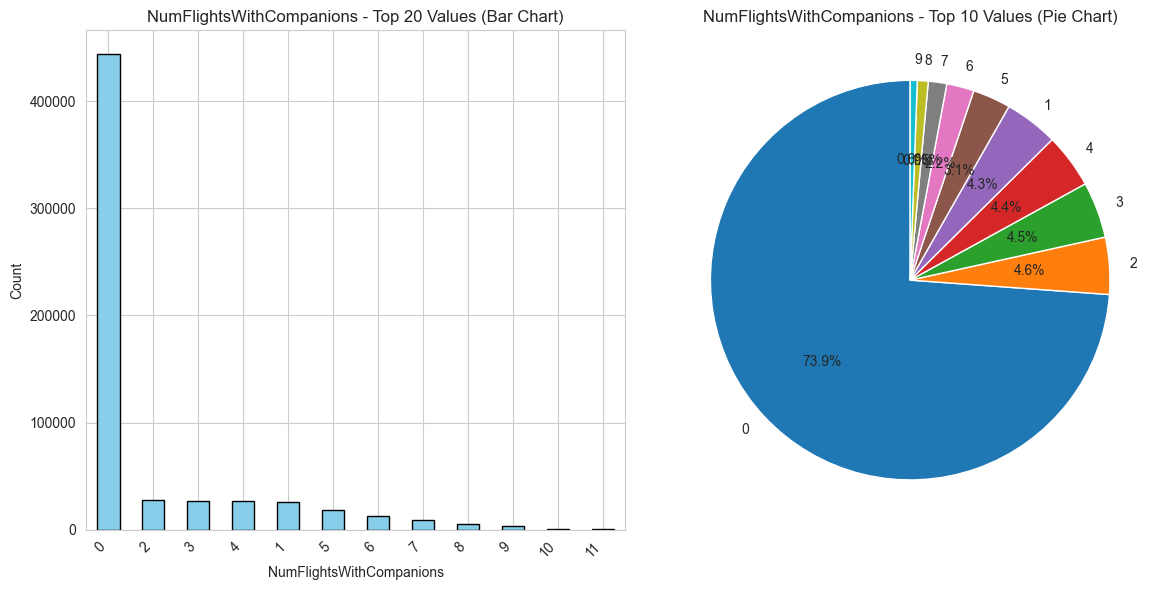

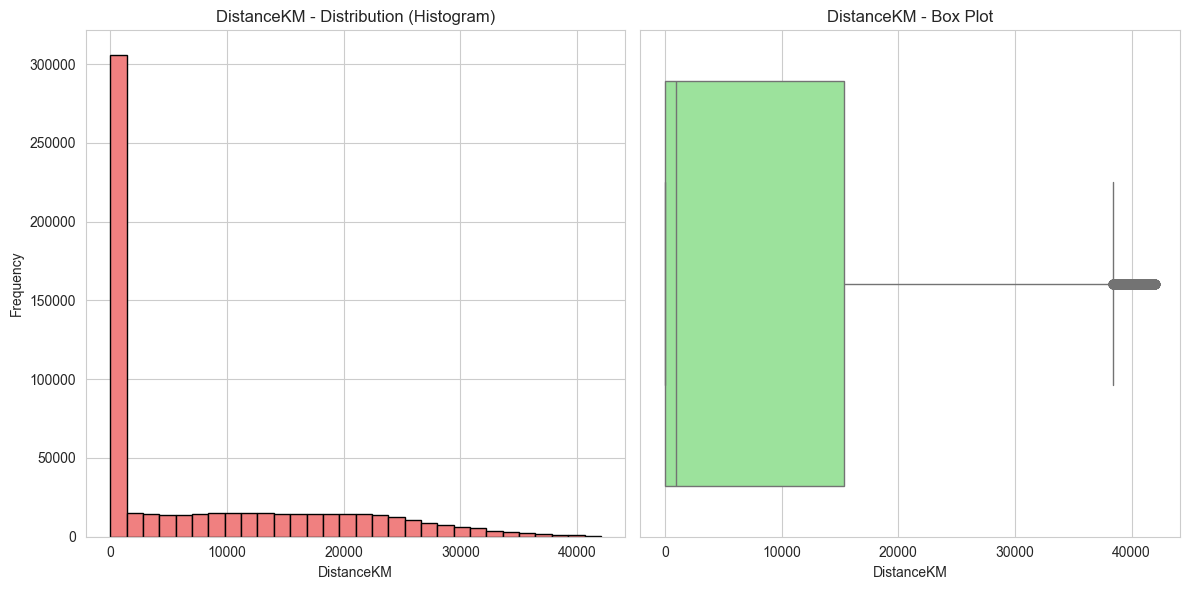

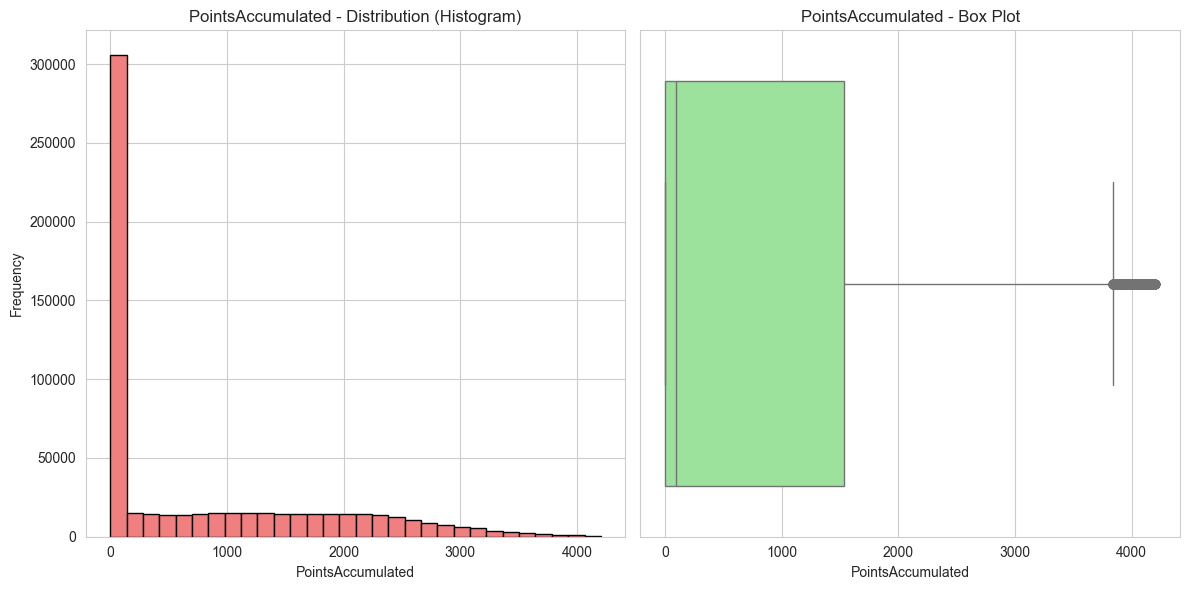

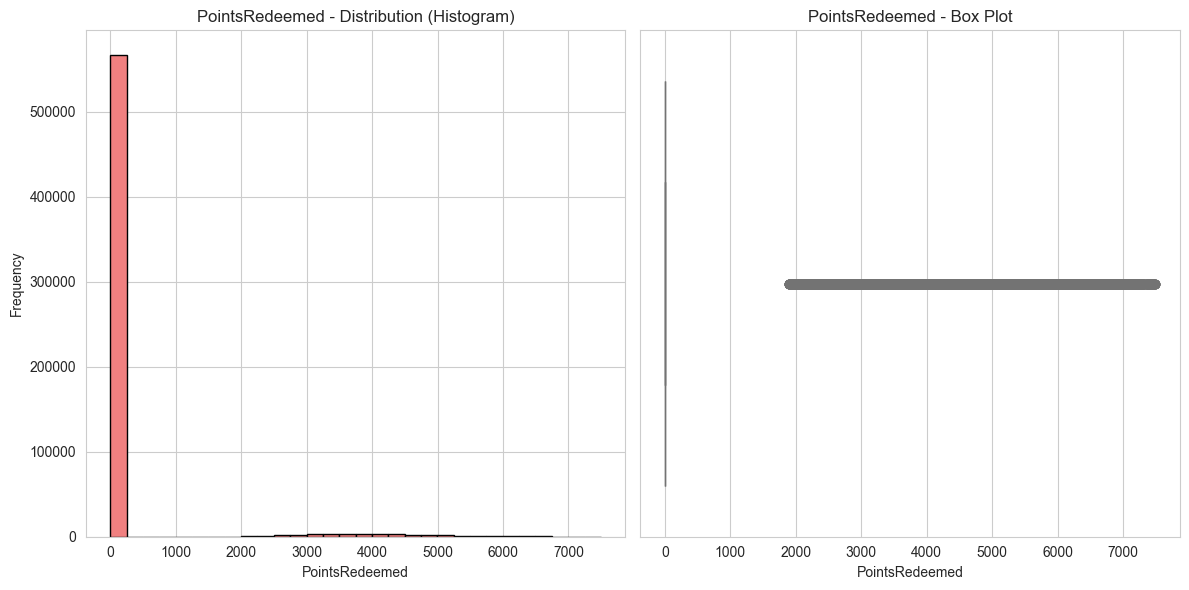

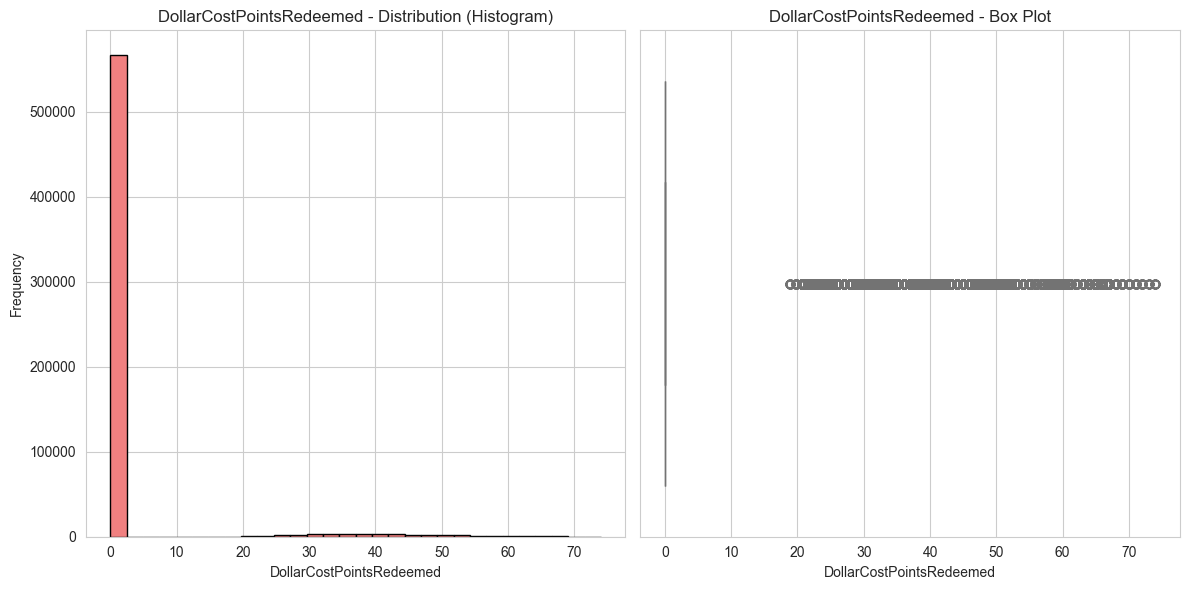

In [19]:
# Visualize distributions of all variables

# Create directory for plots
output_dir = 'Plots'
os.makedirs(output_dir, exist_ok=True)

# Plot distributions for each column
for column in df_final.columns:
    plt.figure(figsize=(12, 6))
    
    # For categorical/object columns or low cardinality
    if df_final[column].dtype == 'object' or df_final[column].nunique() < 50:
        value_counts = df_final[column].value_counts().head(20)
        
        # Bar plot
        plt.subplot(1, 2, 1)
        value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
        plt.title(f'{column} - Top 20 Values (Bar Chart)')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        
        # Pie chart for top 10
        plt.subplot(1, 2, 2)
        value_counts.head(10).plot(kind='pie', autopct='%1.1f%%', startangle=90)
        plt.title(f'{column} - Top 10 Values (Pie Chart)')
        plt.ylabel('')
        
    # For numerical columns
    else:
        # Histogram
        plt.subplot(1, 2, 1)
        df_final[column].hist(bins=30, color='lightcoral', edgecolor='black')
        plt.title(f'{column} - Distribution (Histogram)')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        
        # Box plot
        plt.subplot(1, 2, 2)
        if pd.api.types.is_numeric_dtype(df_final[column]):
            sns.boxplot(x=df_final[column], color='lightgreen')
        else:
            plt.text(0.5, 0.5, 'Non-numeric data', fontsize=12, ha='center', va='center')
        plt.title(f'{column} - Box Plot')
        plt.xlabel(column)
    
    plt.tight_layout()
    
    # Save plot
    clean_column_name = column.replace(' ', '_').replace('#', 'num').replace('/', '_').replace('.', '_')
    filename = f'{output_dir}/{clean_column_name}_plot.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()

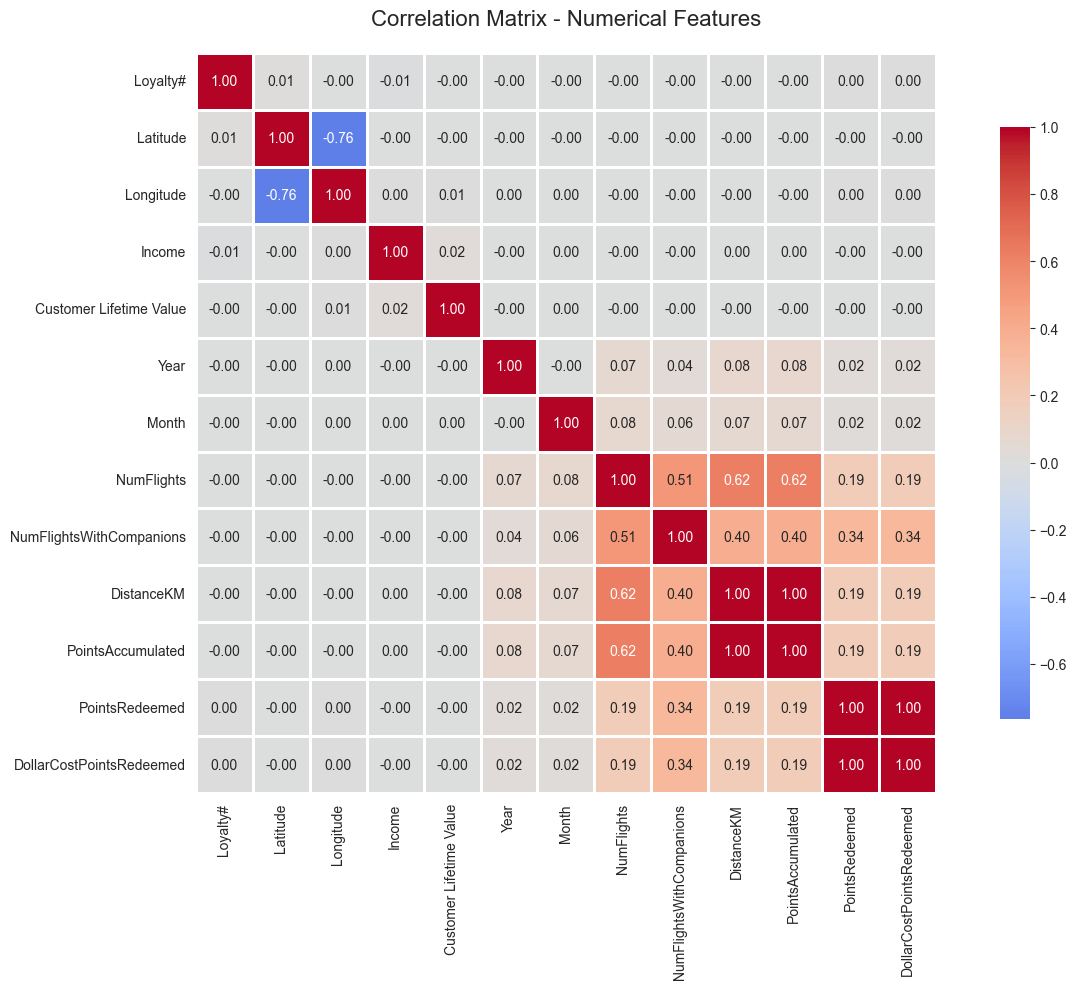

In [20]:
# Calculate correlation matrix for numerical features
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
correlation_matrix = df_final[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**Key Observations from Descriptive Statistics**:
- **Distribution patterns**: Income and CLV show strong right-skew, indicating a small segment of high-value customers
- **Outliers detected**: Flight distance and points accumulated contain extreme values requiring robust scaling
- **Categorical balance**: Education and marital status show reasonable distribution, while loyalty tiers may be imbalanced
- **Correlations**: Strong positive correlation between points accumulated and flight distance suggests travel intensity drives rewards

## 4. Feature Engineering

Creating derived variables that capture richer behavioral patterns and customer characteristics for more effective segmentation.

In [21]:
# Calculate average metrics per flight
df_final['avg_km_per_flight'] = df_final['DistanceKM'] / (df_final['NumFlights'] + 1)
df_final['avg_points_per_flight'] = df_final['PointsAccumulated'] / (df_final['NumFlights'] + 1)

display(df_final[['NumFlights', 'DistanceKM', 'avg_km_per_flight', 
                   'PointsAccumulated', 'avg_points_per_flight']].describe())

,NumFlights,DistanceKM,avg_km_per_flight,PointsAccumulated,avg_points_per_flight
count,602532.0,602532.000000,602532.0,602532.000000,602532.0
mean,3.919969,7955.196144,1385.625846,795.362893,138.535111
std,5.064625,10263.557090,2711.524156,1026.232111,271.114588
min,0.0,0.000000,0.0,0.000000,0.0
25%,0.0,0.000000,0.0,0.000000,0.0
50%,1.0,919.000000,110.528182,91.845000,11.0
75%,7.0,15367.000000,1815.169118,1536.322500,181.5
max,21.0,42040.000000,40109.0,4204.000000,4010.0


In [22]:
# Ensure 'Points Redeemed' exists in df_flights before merging
if 'PointsRedeemed' in df_flights.columns:
    if 'PointsRedeemed' not in df_final.columns:
        df_final = pd.merge(df_final, df_flights[['Loyalty#', 'PointsRedeemed']], on='Loyalty#', how='left')

    # Calculate redemption behavior (redeemed vs accumulated)
    df_final['redemption_ratio'] = df_final['PointsRedeemed'] / (df_final['PointsAccumulated'] + 1)
    df_final['points_balance'] = df_final['PointsAccumulated'] - df_final['PointsRedeemed']

    display(df_final[['PointsAccumulated', 'PointsRedeemed', 
                       'redemption_ratio', 'points_balance']].describe())

,PointsAccumulated,PointsRedeemed,redemption_ratio,points_balance
count,602532.000000,602532.000000,602532.000000,602532.000000
mean,795.362893,235.805094,0.352589,559.557799
std,1026.232111,984.379949,3.196012,1280.980208
min,0.000000,0.000000,0.000000,-7357.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,91.845000,0.000000,0.000000,0.000000
75%,1536.322500,0.000000,0.000000,1348.000000
max,4204.000000,7496.000000,144.419355,4204.000000


In [23]:
# Calculate temporal features
df_final['active_days'] = (df_final['CancellationDate'].fillna(pd.Timestamp.now()) - 
                            df_final['EnrollmentDateOpening']).dt.days

# Recency: months since last flight activity
current_date = pd.Timestamp(df_final['Year'].max(), df_final['Month'].max(), 1)
df_final['months_since_flight'] = ((current_date.year - df_final['Year']) * 12 + 
                                    (current_date.month - df_final['Month']))

display(df_final[['EnrollmentDateOpening', 'active_days', 
                   'Year', 'Month', 'months_since_flight']].describe())

,EnrollmentDateOpening,active_days,Year,Month,months_since_flight
count,602532,602532.000000,602532.000000,602532.000000,602532.000000
mean,2018-10-06 20:55:11.561211904,2294.478162,2020.000000,6.500000,17.500000
min,2015-04-01 00:00:00,-1924.000000,2019.000000,1.000000,0.000000
25%,2017-01-18 00:00:00,1680.000000,2019.000000,3.750000,8.750000
50%,2018-11-02 00:00:00,2370.000000,2020.000000,6.500000,17.500000
75%,2020-07-10 00:00:00,3142.000000,2021.000000,9.250000,26.250000
max,2021-12-30 00:00:00,3870.000000,2021.000000,12.000000,35.000000
std,NaN,1045.068854,0.816497,3.452055,10.388303


In [24]:
# Calculate companion ratio (traveling with others)
df_final['companion_ratio'] = df_final['NumFlightsWithCompanions'] / (df_final['NumFlights'] + 1)

display(df_final[['NumFlights', 'NumFlightsWithCompanions', 'companion_ratio']].describe())

,NumFlights,NumFlightsWithCompanions,companion_ratio
count,602532.0,602532.0,602532.0
mean,3.919969,0.988193,0.126454
std,5.064625,1.994808,0.242593
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,1.0,0.0,0.0
75%,7.0,1.0,0.111111
max,21.0,11.0,0.916667


In [25]:
# Calculate value-to-activity ratios
df_final['clv_per_flight'] = df_final['Customer Lifetime Value'] / (df_final['NumFlights'] + 1)
df_final['clv_to_salary_ratio'] = df_final['Customer Lifetime Value'] / (df_final['Income'] + 1)

display(df_final[['Customer Lifetime Value', 'NumFlights', 'Income',
                   'clv_per_flight', 'clv_to_salary_ratio']].describe())

,Customer Lifetime Value,NumFlights,Income,clv_per_flight,clv_to_salary_ratio
count,602532.000000,602532.0,602532.000000,602532.0,602532.000000
mean,7988.896536,3.919969,37749.877696,4648.379483,1923.192432
std,6860.783006,5.064625,30369.454458,6077.837521,4671.427384
min,1898.010000,0.0,0.000000,90.413333,0.024845
25%,3980.840000,0.0,0.000000,773.96,0.095576
50%,5780.180000,1.0,34148.000000,2674.996667,0.200411
75%,8940.580000,7.0,62396.000000,5989.77,2124.170000
max,83325.380000,21.0,99981.000000,83325.38,74228.520000


In [26]:
# Dictionary to map loyalty tiers to numeric values
loyalty_mapping = {'Star': 1, 'Nova': 2, 'Aurora': 3}
df_final['loyalty_tier_numeric'] = df_final['LoyaltyStatus'].map(loyalty_mapping)

df_final.groupby(['LoyaltyStatus', 'loyalty_tier_numeric']).size()

LoyaltyStatus  loyalty_tier_numeric
Aurora         3                       123444
Nova           2                       204156
Star           1                       274932
dtype: int64

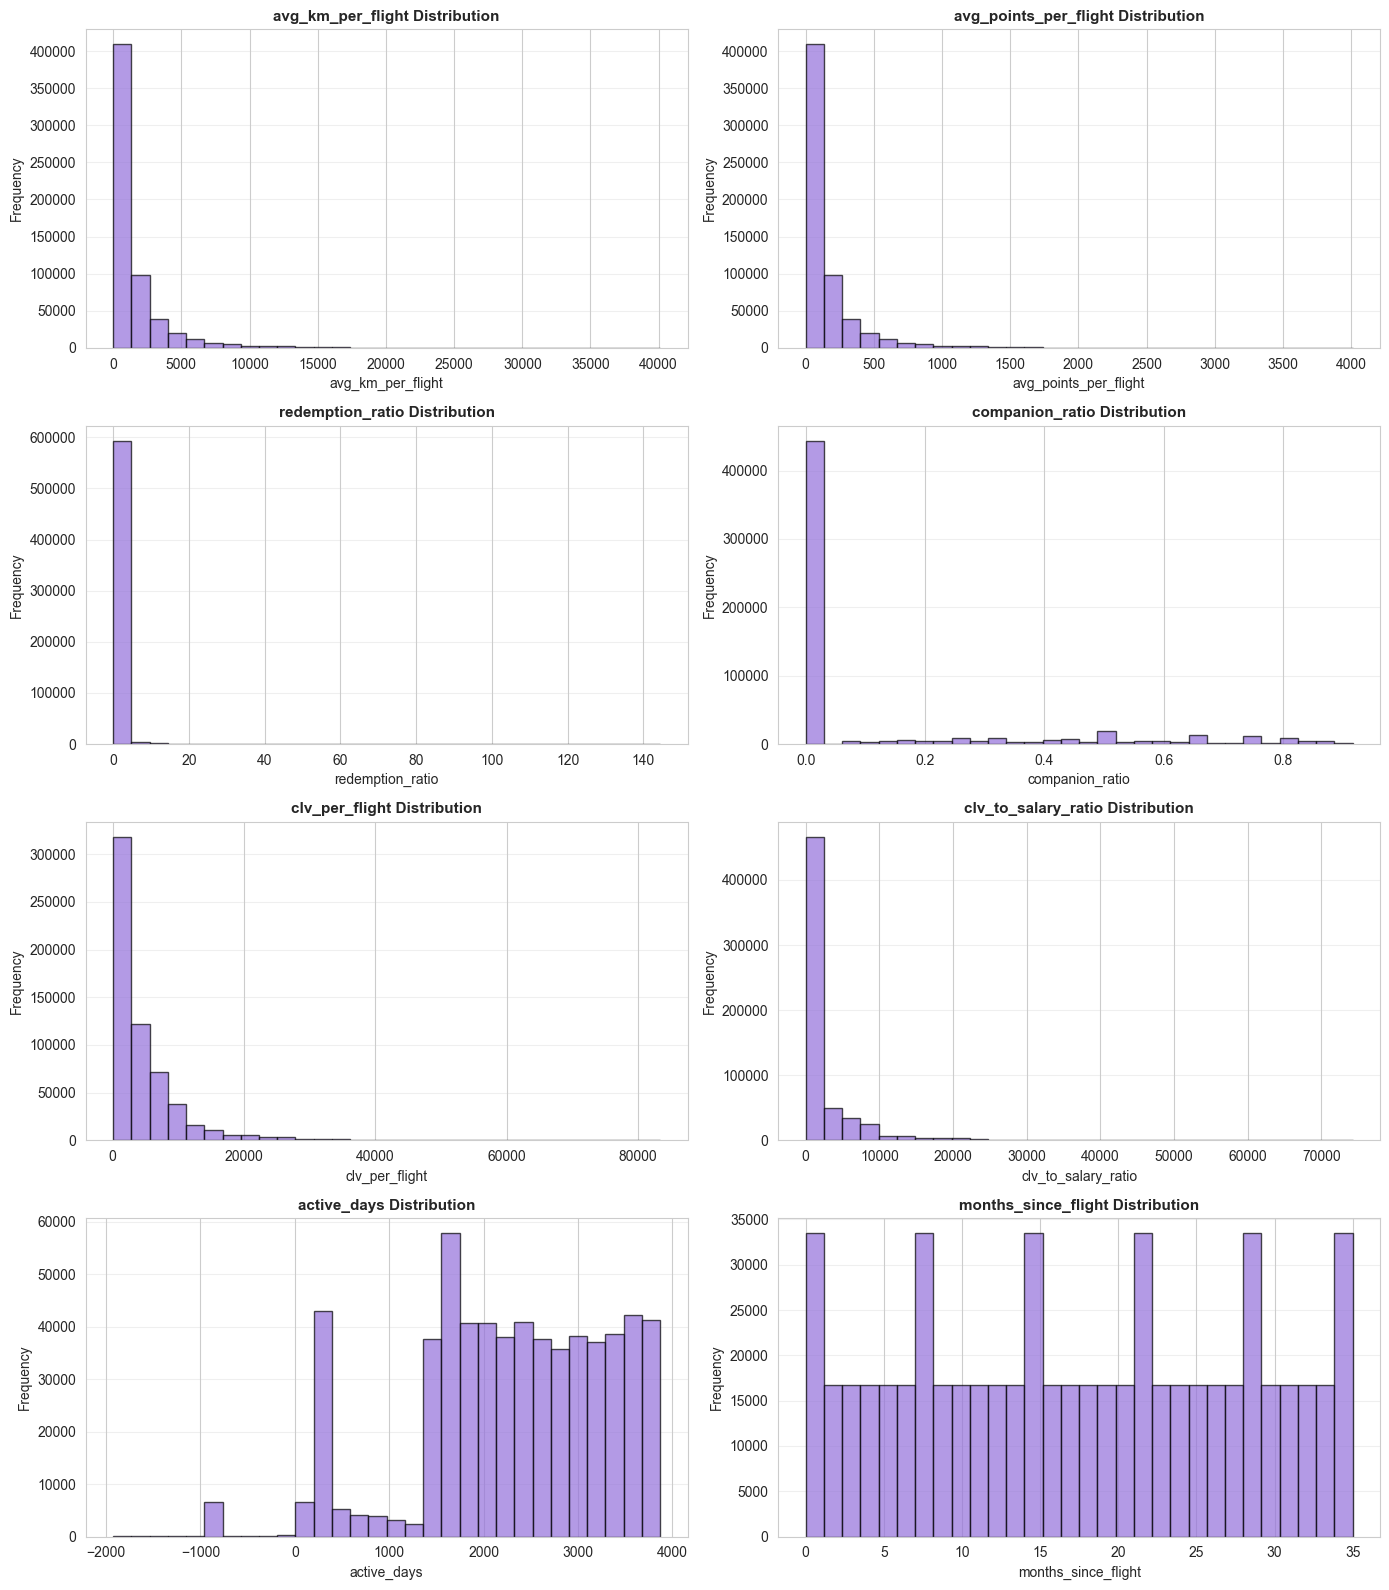

✓ Engineered features visualized and saved


In [27]:
# Visualize engineered features distributions
engineered_features = [
    'avg_km_per_flight', 'avg_points_per_flight', 'redemption_ratio',
    'companion_ratio', 'clv_per_flight', 'clv_to_salary_ratio',
    'active_days', 'months_since_flight'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel()

for idx, feature in enumerate(engineered_features):
    if feature in df_final.columns:
        axes[idx].hist(df_final[feature].dropna(), bins=30, color='mediumpurple', 
                      edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{feature} Distribution', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{output_dir}/engineered_features_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Engineered features visualized and saved")

**Feature Engineering Rationale**:

1. **avg_km_per_flight**: Distinguishes short-haul frequent travelers from long-haul occasional travelers
2. **redemption_ratio**: Identifies savers (low ratio) vs. spenders (high ratio) among loyal customers
3. **active_days**: Captures customer tenure and long-term engagement with the program
4. **companion_ratio**: Reveals solo business travelers vs. leisure family travelers
5. **clv_per_flight**: Measures value contribution per trip, identifying premium vs. budget customers
6. **clv_to_salary_ratio**: Uncovers customers who overspend relative to income (aspirational segment)
7. **months_since_flight**: Recency metric for identifying dormant or at-risk customers
8. **avg_points_per_flight**: Indicates preference for point-earning routes or fare classes

These engineered variables capture multi-dimensional behavioral patterns beyond raw counts, enabling more nuanced customer segmentation.

## 5. Behavioral Insights for Segmentation

Exploring relationships between features to identify preliminary customer groups and validate segmentation potential.

C:\Users\diogo\AppData\Local\Temp\ipykernel_32904\2794463748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='LoyaltyStatus', y='Customer Lifetime Value', data=df_final,


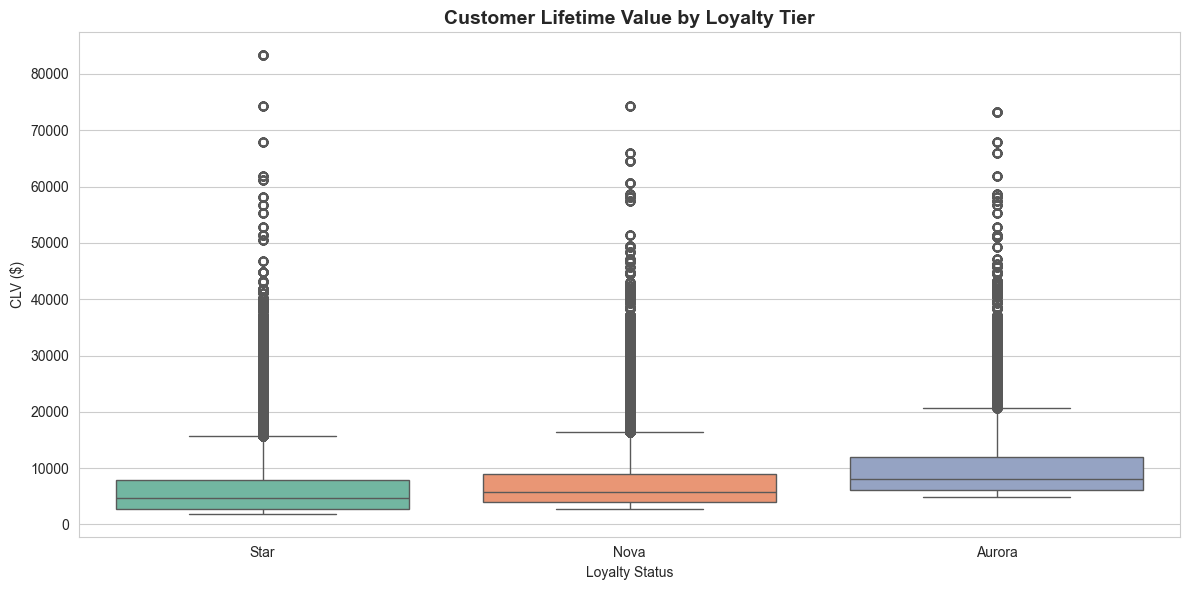

                  count          mean          std      min      25%      50%  \
LoyaltyStatus                                                                   
Aurora         123444.0  10672.686325  7527.846163  4936.89  6063.20  8140.00   
Nova           204156.0   8045.615995  6699.636840  2738.00  4015.34  5799.06   
Star           274932.0   6741.761372  6292.222640  1898.01  2725.32  4786.89   

                    75%       max  
LoyaltyStatus                      
Aurora         11895.18  73225.96  
Nova            8962.80  74228.52  
Star            7897.02  83325.38  


In [28]:
# Compare customer lifetime value across loyalty tiers
plt.figure(figsize=(12, 6))
sns.boxplot(x='LoyaltyStatus', y='Customer Lifetime Value', data=df_final, 
            order=['Star', 'Nova', 'Aurora'], palette='Set2')
plt.title('Customer Lifetime Value by Loyalty Tier', fontsize=14, fontweight='bold')
plt.xlabel('Loyalty Status')
plt.ylabel('CLV ($)')
plt.tight_layout()
plt.savefig(f'{output_dir}/clv_by_loyalty_tier.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical summary
print(df_final.groupby('LoyaltyStatus')['Customer Lifetime Value'].describe())

C:\Users\diogo\AppData\Local\Temp\ipykernel_32904\1705207185.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='NumFlights', data=df_final, ax=axes[0], palette='muted')
C:\Users\diogo\AppData\Local\Temp\ipykernel_32904\1705207185.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\diogo\AppData\Local\Temp\ipykernel_32904\1705207185.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='DistanceKM', data=df_final, ax=axes[1], palette='muted')
C:\Users\diogo\AppData\Local\Temp\ipykernel_32904

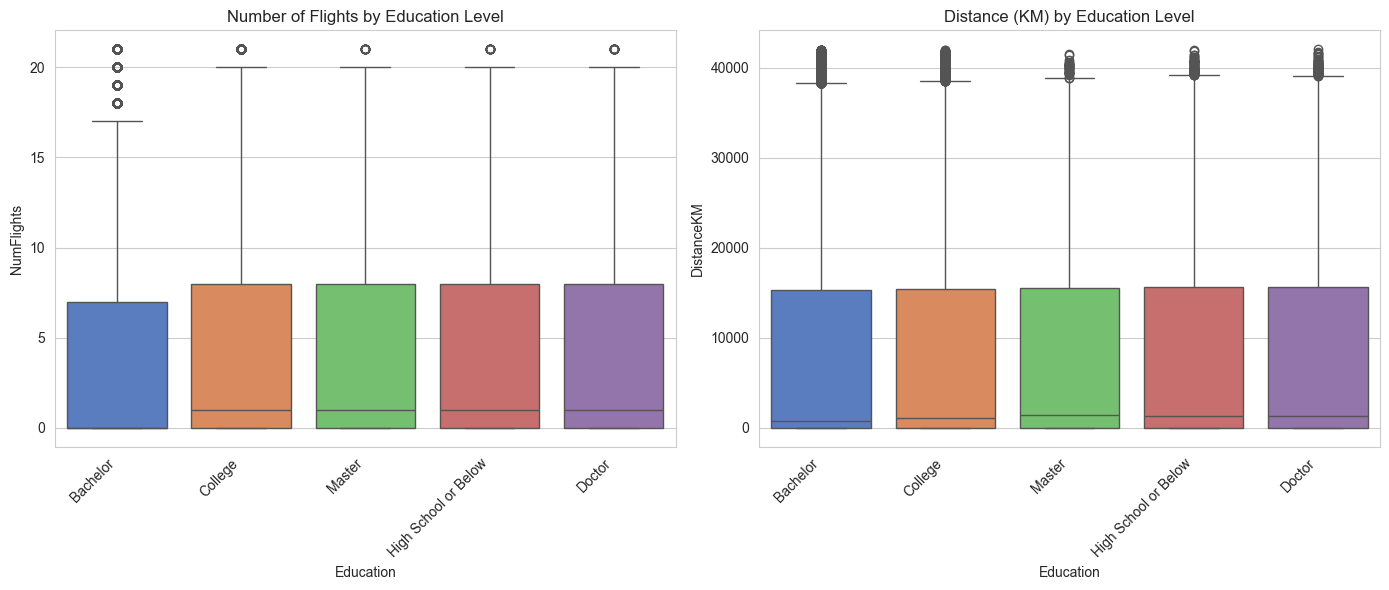

In [29]:
# Compare flight patterns across education levels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Education', y='NumFlights', data=df_final, ax=axes[0], palette='muted')
axes[0].set_title('Number of Flights by Education Level')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.boxplot(x='Education', y='DistanceKM', data=df_final, ax=axes[1], palette='muted')
axes[1].set_title('Distance (KM) by Education Level')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f'{output_dir}/flight_behavior_by_education.png', dpi=300, bbox_inches='tight')
plt.show()

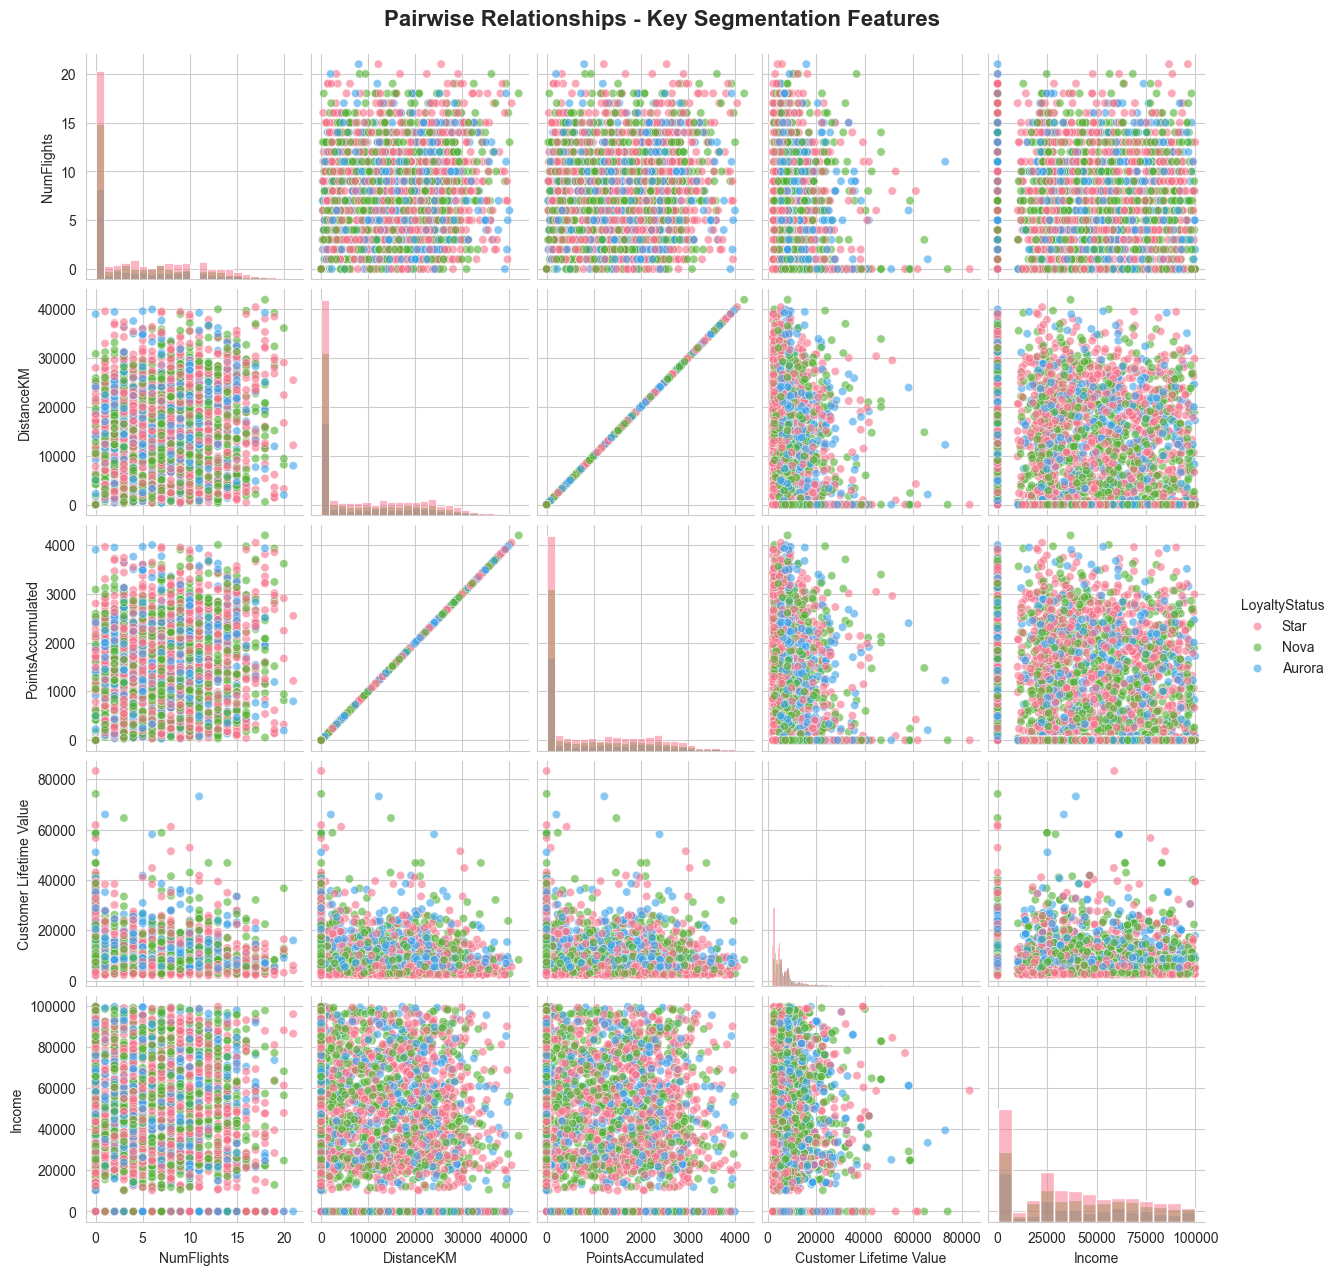

✓ Pairplot reveals potential clustering structure


In [30]:
# Multi-dimensional visualization to identify natural clusters
key_features = ['NumFlights', 'DistanceKM', 'PointsAccumulated', 
                'Customer Lifetime Value', 'Income']

# Sample for performance (if dataset is large)
sample_size = min(5000, len(df_final))
df_sample = df_final[key_features + ['LoyaltyStatus']].sample(n=sample_size, random_state=42)

pairplot = sns.pairplot(df_sample, hue='LoyaltyStatus', palette='husl', 
                        plot_kws={'alpha': 0.6}, diag_kind='hist')
pairplot.fig.suptitle('Pairwise Relationships - Key Segmentation Features', 
                       y=1.02, fontsize=16, fontweight='bold')
plt.savefig(f'{output_dir}/pairplot_segmentation_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Pairplot reveals potential clustering structure")

C:\Users\diogo\AppData\Local\Temp\ipykernel_32904\1709579424.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='LoyaltyStatus', y='redemption_ratio', data=df_final,


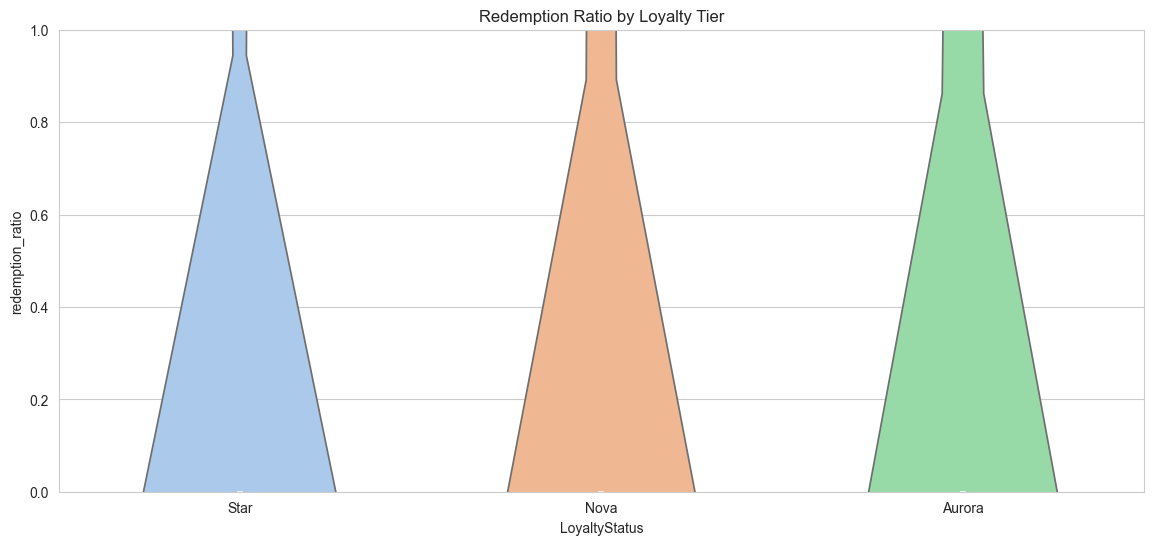

In [31]:
# Compare redemption patterns and companion behavior
fig, axes = plt.subplots(1, figsize=(14, 6))

# Redemption ratio by loyalty tier
sns.violinplot(x='LoyaltyStatus', y='redemption_ratio', data=df_final, 
               order=['Star', 'Nova', 'Aurora'], ax=axes, palette='pastel')
axes.set_title('Redemption Ratio by Loyalty Tier')
axes.set_ylim(0, 1)

plt.savefig(f'{output_dir}/behavioral_patterns_comparison.png', dpi=300, bbox_inches='tight')
plt.show()